In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

# List the contents of the root directory of your Google Drive
print(os.listdir('/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/bkai_foundation_models_fine_tuning_v1'))

['eval', '1_Pooling', 'model.safetensors', 'bpe.codes', 'vocab.txt', 'config_sentence_transformers.json', 'config.json', 'tokenizer_config.json', 'special_tokens_map.json', 'added_tokens.json', 'modules.json', 'sentence_bert_config.json', 'README.md']


In [ ]:
# import os
# import pickle
# from sklearn.model_selection import train_test_split

# # ================================
# # 1) ĐƯỜNG DẪN TỆP GỐC
# # ================================
# data_path = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/data_train_singlequery.pkl"

# # ================================
# # 2) ĐƯỜNG DẪN LƯU SPLIT
# # ================================
# split_dir = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/splits"
# os.makedirs(split_dir, exist_ok=True)

# train_out = os.path.join(split_dir, "train_pairs_v1.pkl")
# val_out   = os.path.join(split_dir, "val_pairs_v1.pkl")
# test_out  = os.path.join(split_dir, "test_pairs_v1.pkl")

# # ================================
# # 3) TẢI DỮ LIỆU
# # ================================
# with open(data_path, "rb") as f:
#     data= pickle.load(f)

# print("Tổng số mẫu:", len(data))

# # ================================
# # 4) CHIA TRAIN / VAL / TEST 80–10–10
# # ================================
# train_pairs, temp_pairs = train_test_split(
#     data, test_size=0.2, random_state=42
# )

# val_pairs, test_pairs = train_test_split(
#     temp_pairs, test_size=0.5, random_state=42
# )

# print(f"Train: {len(train_pairs)} | Val: {len(val_pairs)} | Test: {len(test_pairs)}")

# # ================================
# # 5) LƯU LẠI 3 TỆP
# # ================================
# with open(train_out, "wb") as f:
#     pickle.dump(train_pairs, f)

# with open(val_out, "wb") as f:
#     pickle.dump(val_pairs, f)

# with open(test_out, "wb") as f:
#     pickle.dump(test_pairs, f)

# print("✓ Đã lưu xong các tệp:")
# print("  -", train_out)
# print("  -", val_out)
# print("  -", test_out)


In [3]:
# Tập dữ liệu
train_pairs = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/splits/train_pairs.pkl'
val_pairs = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/splits/val_pairs.pkl'
test_pairs = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/data_train/data_final_train_v1/splits/test_pairs.pkl'


In [4]:
# ----------------------------
# 1) HÀM LOAD DỮ LIỆU CẶP (query - positive)
# ----------------------------
from pathlib import Path
import pickle
from typing import List
from sentence_transformers import InputExample

def load_pairs(pkl_path: Path, preview: int = 2) -> List[InputExample]:
    """
    Đọc file .pkl chứa danh sách InputExample (mỗi mẫu gồm 2 trường: query và passage).
    - pkl_path: đường dẫn tới file .pkl chứa dữ liệu.
    - preview: số lượng mẫu đầu tiên sẽ được in ra để kiểm tra.
    Trả về: list các InputExample (định dạng chuẩn cho SentenceTransformers).
    """

    # Mở file pickle và load dữ liệu gốc (list object)
    with open(pkl_path, "rb") as f:
        data = pickle.load(f)

    pairs = []     # danh sách lưu các cặp hợp lệ (query–positive)
    i = 0          # đếm số mẫu đã đọc

    for ex in data:
        # Bỏ qua nếu không phải kiểu InputExample (phòng trường hợp file lẫn object khác)
        if not isinstance(ex, InputExample):
            continue

        texts = ex.texts  # texts là list chứa các chuỗi, vd: ["query", "positive"]

        # Chỉ lấy các mẫu có đúng 2 trường (query & positive)
        if len(texts) == 2:
            q = f"{texts[0].strip()}"   # câu hỏi / truy vấn
            p = f"{texts[1].strip()}"   # đoạn văn bản trả lời tương ứng
            # Tạo một đối tượng InputExample mới (giữ nguyên format)
            pairs.append(InputExample(texts=[texts[0], texts[1]]))
        else:
            continue  # bỏ qua nếu mẫu không hợp lệ (vd. 1 hoặc 3+ trường)

        # Hiển thị trước một vài mẫu đầu để kiểm tra
        if i < preview:
            print(f"\n🔹 Mẫu {i+1}:")
            print(f"{q}")
            print(f"{p[:150]}")  # chỉ in 150 ký tự đầu của passage cho gọn

        i += 1

    #  Lưu ý: dòng gốc của bạn có bug vì gọi 'triplets' (chưa định nghĩa)
    # → phải sửa lại thành 'pairs'
    print(f"\n Tổng số mẫu hợp lệ: {len(pairs)}")

    return pairs

# pairs: List[InputExample] = load_pairs(INPUT_FILE_PATH)

In [5]:
train_pairs = load_pairs(train_pairs)
val_pairs   = load_pairs(val_pairs)
test_pairs  = load_pairs(test_pairs)

print(" Train pairs:", len(train_pairs))
print(" Val pairs:", len(val_pairs))
print(" Test pairs:", len(test_pairs))


🔹 Mẫu 1:
query: Theo tập tục người Chăm xưa, lễ nhập hồn vào tượng Kut được thực hiện cho ai khi qua đời?
passage: Theo tập tục người Chăm xưa, những vua, quan khi chết sẽ được làm lễ nhập hồn vào tượng Kut. Tiếp theo sẽ đến một không gian trưng ba

🔹 Mẫu 2:
query: Hành trình thăm viếng từ chùa Lôi Âm sẽ dẫn du khách đến những địa điểm nào?
passage: Hành trình thăm viếng sẽ bắt đầu từ chùa Lôi Âm tọa lạc trên một vùng đất rộng, bằng phẳng, xung quanh là cây cối um tùm, trầm lắng. Theo con

 Tổng số mẫu hợp lệ: 12771

🔹 Mẫu 1:
query: Bạn có biết những món ăn đặc sắc nào ở các quốc gia Đông Nam Á mà bạn không nên bỏ qua khi trải nghiệm ẩm thực tại Quảng Nam?
passage: Một vòng trải nghiệm ẩm thực Đông Nam Á: Ẩm thực là phần không thể thiếu trong mỗi hành trình khám phá các miền đất mới. Mảnh đất Đông Nam Á 

🔹 Mẫu 2:
query: Bơ sáp Đăk Mil có những đặc điểm gì nổi bật về vỏ, thịt và hương vị?
passage: Bơ sáp Đăk Mil. Bơ sáp Đăk Mil vỏ mỏng và trơn láng. Khi chín, thịt trái bơ có

In [6]:
from __future__ import annotations

import heapq
import json
import logging
import os
from typing import TYPE_CHECKING, Callable

import numpy as np
import torch
from torch import Tensor
from tqdm import trange

from sentence_transformers.evaluation.SentenceEvaluator import SentenceEvaluator
from sentence_transformers.similarity_functions import SimilarityFunction

if TYPE_CHECKING:
    from sentence_transformers.SentenceTransformer import SentenceTransformer

logger = logging.getLogger(__name__)


class InformationRetrievalEvaluator(SentenceEvaluator):

    """
    This class evaluates an Information Retrieval (IR) setting.

    Given a set of queries and a large corpus set. It will retrieve for each query the top-k most similar document. It measures
    Mean Reciprocal Rank (MRR), Recall@k, and Normalized Discounted Cumulative Gain (NDCG)

    Args:
        queries (Dict[str, str]): A dictionary mapping query IDs to queries.
        corpus (Dict[str, str]): A dictionary mapping document IDs to documents.
        relevant_docs (Dict[str, Set[str]]): A dictionary mapping query IDs to a set of relevant document IDs.
        corpus_chunk_size (int): The size of each chunk of the corpus. Defaults to 50000.
        mrr_at_k (List[int]): A list of integers representing the values of k for MRR calculation. Defaults to [10].
        ndcg_at_k (List[int]): A list of integers representing the values of k for NDCG calculation. Defaults to [10].
        accuracy_at_k (List[int]): A list of integers representing the values of k for accuracy calculation. Defaults to [1, 3, 5, 10].
        precision_recall_at_k (List[int]): A list of integers representing the values of k for precision and recall calculation. Defaults to [1, 3, 5, 10].
        map_at_k (List[int]): A list of integers representing the values of k for MAP calculation. Defaults to [100].
        show_progress_bar (bool): Whether to show a progress bar during evaluation. Defaults to False.
        batch_size (int): The batch size for evaluation. Defaults to 32.
        name (str): A name for the evaluation. Defaults to "".
        write_csv (bool): Whether to write the evaluation results to a CSV file. Defaults to True.
        truncate_dim (int, optional): The dimension to truncate the embeddings to. Defaults to None.
        score_functions (Dict[str, Callable[[Tensor, Tensor], Tensor]]): A dictionary mapping score function names to score functions. Defaults to the ``similarity`` function from the ``model``.
        main_score_function (Union[str, SimilarityFunction], optional): The main score function to use for evaluation. Defaults to None.
        query_prompt (str, optional): The prompt to be used when encoding the corpus. Defaults to None.
        query_prompt_name (str, optional): The name of the prompt to be used when encoding the corpus. Defaults to None.
        corpus_prompt (str, optional): The prompt to be used when encoding the corpus. Defaults to None.
        corpus_prompt_name (str, optional): The name of the prompt to be used when encoding the corpus. Defaults to None.
        write_predictions (bool): Whether to write the predictions to a JSONL file. Defaults to False.
            This can be useful for downstream evaluation as it can be used as input to the :class:`~sentence_transformers.sparse_encoder.evaluation.ReciprocalRankFusionEvaluator` that accept precomputed predictions.

    Example:
        ::

            import random
            from sentence_transformers import SentenceTransformer
            from sentence_transformers.evaluation import InformationRetrievalEvaluator
            from datasets import load_dataset

            # Load a model
            model = SentenceTransformer('all-MiniLM-L6-v2')

            # Load the Touche-2020 IR dataset (https://huggingface.co/datasets/BeIR/webis-touche2020, https://huggingface.co/datasets/BeIR/webis-touche2020-qrels)
            corpus = load_dataset("BeIR/webis-touche2020", "corpus", split="corpus")
            queries = load_dataset("BeIR/webis-touche2020", "queries", split="queries")
            relevant_docs_data = load_dataset("BeIR/webis-touche2020-qrels", split="test")

            # For this dataset, we want to concatenate the title and texts for the corpus
            corpus = corpus.map(lambda x: {'text': x['title'] + " " + x['text']}, remove_columns=['title'])

            # Shrink the corpus size heavily to only the relevant documents + 30,000 random documents
            required_corpus_ids = set(map(str, relevant_docs_data["corpus-id"]))
            required_corpus_ids |= set(random.sample(corpus["_id"], k=30_000))
            corpus = corpus.filter(lambda x: x["_id"] in required_corpus_ids)

            # Convert the datasets to dictionaries
            corpus = dict(zip(corpus["_id"], corpus["text"]))  # Our corpus (cid => document)
            queries = dict(zip(queries["_id"], queries["text"]))  # Our queries (qid => question)
            relevant_docs = {}  # Query ID to relevant documents (qid => set([relevant_cids])
            for qid, corpus_ids in zip(relevant_docs_data["query-id"], relevant_docs_data["corpus-id"]):
                qid = str(qid)
                corpus_ids = str(corpus_ids)
                if qid not in relevant_docs:
                    relevant_docs[qid] = set()
                relevant_docs[qid].add(corpus_ids)

            # Given queries, a corpus and a mapping with relevant documents, the InformationRetrievalEvaluator computes different IR metrics.
            ir_evaluator = InformationRetrievalEvaluator(
                queries=queries,
                corpus=corpus,
                relevant_docs=relevant_docs,
                name="BeIR-touche2020-subset-test",
            )
            results = ir_evaluator(model)
            '''
            Information Retrieval Evaluation of the model on the BeIR-touche2020-test dataset:
            Queries: 49
            Corpus: 31923

            Score-Function: cosine
            Accuracy@1: 77.55%
            Accuracy@3: 93.88%
            Accuracy@5: 97.96%
            Accuracy@10: 100.00%
            Precision@1: 77.55%
            Precision@3: 72.11%
            Precision@5: 71.43%
            Precision@10: 62.65%
            Recall@1: 1.72%
            Recall@3: 4.78%
            Recall@5: 7.90%
            Recall@10: 13.86%
            MRR@10: 0.8580
            NDCG@10: 0.6606
            MAP@100: 0.2934
            '''
            print(ir_evaluator.primary_metric)
            # => "BeIR-touche2020-test_cosine_map@100"
            print(results[ir_evaluator.primary_metric])
            # => 0.29335196224364596
    """

    def __init__(
        self,
        queries: dict[str, str],  # qid => query
        corpus: dict[str, str],  # cid => doc
        relevant_docs: dict[str, set[str]],  # qid => Set[cid]
        corpus_chunk_size: int = 50000,
        mrr_at_k: list[int] = [10],
        ndcg_at_k: list[int] = [10],
        accuracy_at_k: list[int] = [1, 3, 5, 10],
        precision_recall_at_k: list[int] = [1, 3, 5, 10],
        map_at_k: list[int] = [100],
        show_progress_bar: bool = False,
        batch_size: int = 32,
        name: str = "",
        write_csv: bool = True,
        truncate_dim: int | None = None,
        score_functions: dict[str, Callable[[Tensor, Tensor], Tensor]] | None = None,
        main_score_function: str | SimilarityFunction | None = None,
        query_prompt: str | None = None,
        query_prompt_name: str | None = None,
        corpus_prompt: str | None = None,
        corpus_prompt_name: str | None = None,
        write_predictions: bool = False,
    ) -> None:
        super().__init__()
        self.queries_ids = []
        for qid in queries:
            if qid in relevant_docs and len(relevant_docs[qid]) > 0:
                self.queries_ids.append(qid)

        self.queries = [queries[qid] for qid in self.queries_ids]

        self.corpus_ids = list(corpus.keys())
        self.corpus = [corpus[cid] for cid in self.corpus_ids]

        self.query_prompt = query_prompt
        self.query_prompt_name = query_prompt_name
        self.corpus_prompt = corpus_prompt
        self.corpus_prompt_name = corpus_prompt_name

        self.relevant_docs = relevant_docs
        self.corpus_chunk_size = corpus_chunk_size
        self.mrr_at_k = mrr_at_k
        self.ndcg_at_k = ndcg_at_k
        self.accuracy_at_k = accuracy_at_k
        self.precision_recall_at_k = precision_recall_at_k
        self.map_at_k = map_at_k

        self.show_progress_bar = show_progress_bar
        self.batch_size = batch_size
        self.name = name
        self.write_csv = write_csv
        self.score_functions = score_functions
        self.score_function_names = sorted(list(self.score_functions.keys())) if score_functions else []
        self.main_score_function = SimilarityFunction(main_score_function) if main_score_function else None
        self.truncate_dim = truncate_dim

        if name:
            name = "_" + name

        self.csv_file: str = "Information-Retrieval_evaluation" + name + "_results.csv"
        self.csv_headers = ["epoch", "steps"]

        self._append_csv_headers(self.score_function_names)
        self.write_predictions = write_predictions
        if self.write_predictions:
            self.predictions_file = "Information-Retrieval_evaluation" + name + "_predictions.jsonl"

    def _append_csv_headers(self, score_function_names):
        for score_name in score_function_names:
            for k in self.accuracy_at_k:
                self.csv_headers.append(f"{score_name}-Accuracy@{k}")

            for k in self.precision_recall_at_k:
                self.csv_headers.append(f"{score_name}-Precision@{k}")
                self.csv_headers.append(f"{score_name}-Recall@{k}")

            for k in self.mrr_at_k:
                self.csv_headers.append(f"{score_name}-MRR@{k}")

            for k in self.ndcg_at_k:
                self.csv_headers.append(f"{score_name}-NDCG@{k}")

            for k in self.map_at_k:
                self.csv_headers.append(f"{score_name}-MAP@{k}")

    def __call__(
        self,
        model: SentenceTransformer,
        output_path: str | None = None,
        epoch: int = -1,
        steps: int = -1,
        *args,
        **kwargs,
    ) -> dict[str, float]:
        if epoch != -1:
            if steps == -1:
                out_txt = f" after epoch {epoch}"
            else:
                out_txt = f" in epoch {epoch} after {steps} steps"
        else:
            out_txt = ""
        if self.truncate_dim is not None:
            out_txt += f" (truncated to {self.truncate_dim})"

        logger.info(f"Information Retrieval Evaluation of the model on the {self.name} dataset{out_txt}:")

        if self.score_functions is None:
            self.score_functions = {model.similarity_fn_name: model.similarity}
            self.score_function_names = [model.similarity_fn_name]
            self._append_csv_headers(self.score_function_names)

        scores = self.compute_metrices(model, output_path=output_path, *args, **kwargs)

        # Write results to disk
        if output_path is not None and self.write_csv:
            os.makedirs(output_path, exist_ok=True)
            csv_path = os.path.join(output_path, self.csv_file)
            if not os.path.isfile(csv_path):
                fOut = open(csv_path, mode="w", encoding="utf-8")
                fOut.write(",".join(self.csv_headers))
                fOut.write("\n")

            else:
                fOut = open(csv_path, mode="a", encoding="utf-8")

            output_data = [epoch, steps]
            for name in self.score_function_names:
                for k in self.accuracy_at_k:
                    output_data.append(scores[name]["accuracy@k"][k])

                for k in self.precision_recall_at_k:
                    output_data.append(scores[name]["precision@k"][k])
                    output_data.append(scores[name]["recall@k"][k])

                for k in self.mrr_at_k:
                    output_data.append(scores[name]["mrr@k"][k])

                for k in self.ndcg_at_k:
                    output_data.append(scores[name]["ndcg@k"][k])

                for k in self.map_at_k:
                    output_data.append(scores[name]["map@k"][k])

            fOut.write(",".join(map(str, output_data)))
            fOut.write("\n")
            fOut.close()

        if not self.primary_metric:
            if self.main_score_function is None:
                score_function = max(
                    [(name, scores[name]["ndcg@k"][max(self.ndcg_at_k)]) for name in self.score_function_names],
                    key=lambda x: x[1],
                )[0]
                self.primary_metric = f"{score_function}_ndcg@{max(self.ndcg_at_k)}"
            else:
                self.primary_metric = f"{self.main_score_function.value}_ndcg@{max(self.ndcg_at_k)}"

        metrics = {
            f"{score_function}_{metric_name.replace('@k', '@' + str(k))}": value
            for score_function, values_dict in scores.items()
            for metric_name, values in values_dict.items()
            for k, value in values.items()
        }
        metrics = self.prefix_name_to_metrics(metrics, self.name)
        self.store_metrics_in_model_card_data(model, metrics, epoch, steps)
        return metrics

    def compute_metrices(
        self,
        model: SentenceTransformer,
        corpus_model=None,
        corpus_embeddings: Tensor | None = None,
        output_path: str | None = None,
    ) -> dict[str, float]:
        if corpus_model is None:
            corpus_model = model

        max_k = max(
            max(self.mrr_at_k),
            max(self.ndcg_at_k),
            max(self.accuracy_at_k),
            max(self.precision_recall_at_k),
            max(self.map_at_k),
        )

        # Compute embedding for the queries
        query_embeddings = self.embed_inputs(
            model,
            self.queries,
            encode_fn_name="query",
            prompt_name=self.query_prompt_name,
            prompt=self.query_prompt,
        )

        queries_result_list = {}
        for name in self.score_functions:
            queries_result_list[name] = [[] for _ in range(len(query_embeddings))]

        # Iterate over chunks of the corpus
        for corpus_start_idx in trange(
            0, len(self.corpus), self.corpus_chunk_size, desc="Corpus Chunks", disable=not self.show_progress_bar
        ):
            corpus_end_idx = min(corpus_start_idx + self.corpus_chunk_size, len(self.corpus))

            # Encode chunk of corpus
            if corpus_embeddings is None:
                sub_corpus_embeddings = self.embed_inputs(
                    corpus_model,
                    self.corpus[corpus_start_idx:corpus_end_idx],
                    encode_fn_name="document",
                    prompt_name=self.corpus_prompt_name,
                    prompt=self.corpus_prompt,
                )
            else:
                sub_corpus_embeddings = corpus_embeddings[corpus_start_idx:corpus_end_idx]

            # Compute cosine similarites
            for name, score_function in self.score_functions.items():
                pair_scores = score_function(query_embeddings, sub_corpus_embeddings)

                # Get top-k values
                pair_scores_top_k_values, pair_scores_top_k_idx = torch.topk(
                    pair_scores, min(max_k, len(pair_scores[0])), dim=1, largest=True, sorted=False
                )
                pair_scores_top_k_values = pair_scores_top_k_values.cpu().tolist()
                pair_scores_top_k_idx = pair_scores_top_k_idx.cpu().tolist()

                for query_itr in range(len(query_embeddings)):
                    for sub_corpus_id, score in zip(
                        pair_scores_top_k_idx[query_itr], pair_scores_top_k_values[query_itr]
                    ):
                        corpus_id = self.corpus_ids[corpus_start_idx + sub_corpus_id]
                        # NOTE: TREC/BEIR/MTEB skips cases where the corpus_id is the same as the query_id, e.g.:
                        # if corpus_id == self.queries_ids[query_itr]:
                        #     continue
                        # This is not done here, as this might be unexpected behaviour if the user just uses
                        # sets of integers from 0 as query_ids and corpus_ids.
                        if len(queries_result_list[name][query_itr]) < max_k:
                            # heaqp tracks the quantity of the first element in the tuple
                            heapq.heappush(queries_result_list[name][query_itr], (score, corpus_id))
                        else:
                            heapq.heappushpop(queries_result_list[name][query_itr], (score, corpus_id))

        for name in queries_result_list:
            for query_itr in range(len(queries_result_list[name])):
                for doc_itr in range(len(queries_result_list[name][query_itr])):
                    score, corpus_id = queries_result_list[name][query_itr][doc_itr]
                    queries_result_list[name][query_itr][doc_itr] = {"corpus_id": corpus_id, "score": score}

        if self.write_predictions and output_path is not None:
            for name in queries_result_list:
                base_filename = self.predictions_file.replace(".jsonl", f"_{name}.jsonl")
                json_path = os.path.join(output_path, base_filename)
                mode = "w"  # Always create a new file for each score function

                with open(json_path, mode=mode, encoding="utf-8") as fOut:
                    for query_itr in range(len(queries_result_list[name])):
                        query_id = self.queries_ids[query_itr]
                        query_text = self.queries[query_itr]
                        results = queries_result_list[name][query_itr]

                        # Sort results by score in descending order
                        results = sorted(results, key=lambda x: x["score"], reverse=True)

                        prediction = {
                            "query_id": query_id,
                            "query": query_text,
                            "results": results,
                        }

                        fOut.write(json.dumps(prediction) + "\n")

        logger.info(f"Queries: {len(self.queries)}")
        logger.info(f"Corpus: {len(self.corpus)}\n")

        # Compute scores
        scores = {name: self.compute_metrics(queries_result_list[name]) for name in self.score_functions}

        # Output
        for name in self.score_function_names:
            logger.info(f"Score-Function: {name}")
            self.output_scores(scores[name])

        return scores

    def embed_inputs(
        self,
        model: SentenceTransformer,
        sentences: str | list[str] | np.ndarray,
        encode_fn_name: str | None = None,
        prompt_name: str | None = None,
        prompt: str | None = None,
        **kwargs,
    ) -> np.ndarray:
        if encode_fn_name is None:
            encode_fn = model.encode
        elif encode_fn_name == "query":
            encode_fn = model.encode_query
        elif encode_fn_name == "document":
            encode_fn = model.encode_document
        return encode_fn(
            sentences,
            prompt_name=prompt_name,
            prompt=prompt,
            batch_size=self.batch_size,
            show_progress_bar=self.show_progress_bar,
            convert_to_tensor=True,
            truncate_dim=self.truncate_dim,
            **kwargs,
        )

    def compute_metrics(self, queries_result_list: list[object]):
        # Init score computation values
        num_hits_at_k = {k: 0 for k in self.accuracy_at_k}
        precisions_at_k = {k: [] for k in self.precision_recall_at_k}
        recall_at_k = {k: [] for k in self.precision_recall_at_k}
        MRR = {k: 0 for k in self.mrr_at_k}
        ndcg = {k: [] for k in self.ndcg_at_k}
        AveP_at_k = {k: [] for k in self.map_at_k}

        # Compute scores on results
        for query_itr in range(len(queries_result_list)):
            query_id = self.queries_ids[query_itr]

            # Sort scores
            top_hits = sorted(queries_result_list[query_itr], key=lambda x: x["score"], reverse=True)
            query_relevant_docs = self.relevant_docs[query_id]

            # Accuracy@k - We count the result correct, if at least one relevant doc is across the top-k documents
            for k_val in self.accuracy_at_k:
                for hit in top_hits[0:k_val]:
                    if hit["corpus_id"] in query_relevant_docs:
                        num_hits_at_k[k_val] += 1
                        break

            # Precision and Recall@k
            for k_val in self.precision_recall_at_k:
                num_correct = 0
                for hit in top_hits[0:k_val]:
                    if hit["corpus_id"] in query_relevant_docs:
                        num_correct += 1

                precisions_at_k[k_val].append(num_correct / k_val)
                recall_at_k[k_val].append(num_correct / len(query_relevant_docs))

            # MRR@k
            for k_val in self.mrr_at_k:
                for rank, hit in enumerate(top_hits[0:k_val]):
                    if hit["corpus_id"] in query_relevant_docs:
                        MRR[k_val] += 1.0 / (rank + 1)
                        break

            # NDCG@k
            for k_val in self.ndcg_at_k:
                predicted_relevance = [
                    1 if top_hit["corpus_id"] in query_relevant_docs else 0 for top_hit in top_hits[0:k_val]
                ]
                true_relevances = [1] * len(query_relevant_docs)

                ndcg_value = self.compute_dcg_at_k(predicted_relevance, k_val) / self.compute_dcg_at_k(
                    true_relevances, k_val
                )
                ndcg[k_val].append(ndcg_value)

            # MAP@k
            for k_val in self.map_at_k:
                num_correct = 0
                sum_precisions = 0

                for rank, hit in enumerate(top_hits[0:k_val]):
                    if hit["corpus_id"] in query_relevant_docs:
                        num_correct += 1
                        sum_precisions += num_correct / (rank + 1)
                avg_precision = sum_precisions / min(k_val, len(query_relevant_docs))
                AveP_at_k[k_val].append(avg_precision)

        # Compute averages
        for k in num_hits_at_k:
            num_hits_at_k[k] /= len(self.queries)

        for k in precisions_at_k:
            precisions_at_k[k] = np.mean(precisions_at_k[k])

        for k in recall_at_k:
            recall_at_k[k] = np.mean(recall_at_k[k])

        for k in ndcg:
            ndcg[k] = np.mean(ndcg[k])

        for k in MRR:
            MRR[k] /= len(self.queries)

        for k in AveP_at_k:
            AveP_at_k[k] = np.mean(AveP_at_k[k])

        return {
            "accuracy@k": num_hits_at_k,
            "precision@k": precisions_at_k,
            "recall@k": recall_at_k,
            "ndcg@k": ndcg,
            "mrr@k": MRR,
            "map@k": AveP_at_k,
        }

    def output_scores(self, scores):
        for k in scores["accuracy@k"]:
            logger.info("Accuracy@{}: {:.2f}%".format(k, scores["accuracy@k"][k] * 100))

        for k in scores["precision@k"]:
            logger.info("Precision@{}: {:.2f}%".format(k, scores["precision@k"][k] * 100))

        for k in scores["recall@k"]:
            logger.info("Recall@{}: {:.2f}%".format(k, scores["recall@k"][k] * 100))

        for k in scores["mrr@k"]:
            logger.info("MRR@{}: {:.4f}".format(k, scores["mrr@k"][k]))

        for k in scores["ndcg@k"]:
            logger.info("NDCG@{}: {:.4f}".format(k, scores["ndcg@k"][k]))

        for k in scores["map@k"]:
            logger.info("MAP@{}: {:.4f}".format(k, scores["map@k"][k]))

    @staticmethod
    def compute_dcg_at_k(relevances, k):
        dcg = 0
        for i in range(min(len(relevances), k)):
            dcg += relevances[i] / np.log2(i + 2)  # +2 as we start our idx at 0
        return dcg

    def get_config_dict(self):
        config_dict = {}
        config_dict_candidate_keys = [
            "truncate_dim",
            "query_prompt",
            "query_prompt_name",
            "corpus_prompt",
            "corpus_prompt_name",
        ]
        for key in config_dict_candidate_keys:
            if getattr(self, key) is not None:
                config_dict[key] = getattr(self, key)
        return config_dict


In [7]:
# =====  Tạo queries / corpus / qrels =====
def ensure_prefix(s: str, kind: str) -> str:
    import re
    s = re.sub(fr"^{kind}:\s*{kind}:\s*", f"{kind}: ", s, flags=re.I)
    return s if s.lower().startswith(f"{kind}:") else f"{kind}: {s}"

def build_ir_inputs(pairs):
    queries, corpus, qrels = {}, {}, {}
    for i, ex in enumerate(pairs):
        if len(ex.texts) != 2:
            continue
        q = ensure_prefix(ex.texts[0].strip(), "query")
        p = ensure_prefix(ex.texts[1].strip(), "passage")
        qid, did = f"q{i}", f"d{i}"
        queries[qid] = q
        corpus[did] = p
        qrels[qid] = {did}
    return queries, corpus, qrels

queries, corpus, qrels = build_ir_inputs(test_pairs)

print(f"Queries: {len(queries)} | Corpus: {len(corpus)} | Qrels: {len(qrels)}")


Queries: 1597 | Corpus: 1597 | Qrels: 1597


**FINE TUNING MODEL intfloat/multilingual-e5-base**

In [50]:
from sentence_transformers import SentenceTransformer

# ===== Load base model =====
BASE_MODEL_E5 = "intfloat/multilingual-e5-base"
print("\n Đang tải model base...")
model_base_e5 = SentenceTransformer(BASE_MODEL_E5)

# ===== Tạo Evaluator (không ghi file) =====
ir_eval = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=qrels,
    mrr_at_k=[10],
    ndcg_at_k=[10],
    accuracy_at_k=[1, 3, 5, 10],
    precision_recall_at_k=[1, 3, 5, 10],
    map_at_k=[100],
    batch_size=64,
    show_progress_bar=True,
)

# ===== Chạy đánh giá (không cần output_path) =====
print("\n=====  BASE MODEL =====")
res_base_e5 = ir_eval(model_base_e5)  #  bỏ output_path

# In kết quả
print("===  Evaluation Results ===")
for metric, value in sorted(res_base_e5.items()):
    print(f"{metric:25s}: {value:.4f}")



 Đang tải model base...


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/694 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:18<00:00, 18.53s/it]

===  Evaluation Results ===
cosine_accuracy@1        : 0.9393
cosine_accuracy@10       : 0.9969
cosine_accuracy@3        : 0.9900
cosine_accuracy@5        : 0.9944
cosine_map@100           : 0.9639
cosine_mrr@10            : 0.9638
cosine_ndcg@10           : 0.9722
cosine_precision@1       : 0.9393
cosine_precision@10      : 0.0997
cosine_precision@3       : 0.3300
cosine_precision@5       : 0.1989
cosine_recall@1          : 0.9393
cosine_recall@10         : 0.9969
cosine_recall@3          : 0.9900
cosine_recall@5          : 0.9944


In [ ]:
# ---------- (A) Chuẩn hóa dữ liệu theo chuẩn E5 ----------
def ensure_e5_prefix(text: str, is_query: bool) -> str:
    p = "query: " if is_query else "passage: "
    return text if text.lower().startswith(p) else (p + text)

def build_e5_pairs_from_pairs(pairs):
    e5_pairs = []
    for ex in pairs:
        q, p = ex.texts[0], ex.texts[1]
        q = ensure_e5_prefix(q, True)
        p = ensure_e5_prefix(p, False)
        e5_pairs.append(InputExample(texts=[q, p]))
    return e5_pairs

train_pairs_e5 = build_e5_pairs_from_pairs(train_pairs)
print(len(train_pairs_e5))
for ex in train_pairs_e5[:3]:
    print(ex.texts)

12571
['query: Bãi Sỏi gần khu du lịch hồ cá Trí Nguyên có những đặc điểm gì nổi bật?', 'passage: Cách khu du lịch hồ cá Trí Nguyên chừng vài trăm mét là bãi Sỏi – bãi tắm còn giữ được vẻ hoang sơ với phía trước mặt là biển, sau lưng là khu rừng với nhiều cây đại thụ và dây leo chằng chịt. Đây là nơi thích hợp với các hoạt động vui chơi, giải trí cho du khách..']
['query: Quán Bún Mọc Bảo Khánh nổi tiếng với những món ăn nào và giá mỗi bát khoảng bao nhiêu tiền?', 'passage: nhưng ở đây tất cả được trình bày rất hài hòa với thịt gà, măng khô xé nhỏ, giò giòn, dai. Quán rất đông khách vào mỗi buổi sáng, giá mỗi bát khoảng 25.000 đồng. Bún mọc Bảo Khánh Quán ăn có thâm niên gần 20 năm từ khi còn ở phố Hàng Hành, sau chuyển về Bảo Khánh với không gian rộng rãi hơn và ngày càng đông khách, nhất là mỗi buổi sáng. Quán nổi tiếng với món bún mọc ngon. Bát bún mọc đầy đặn với chả quế, giò sống, nấm hương và gà xé đầy đủ chất dinh dưỡng. Giá khoảng 30.000 đồng một bát.']
['query: Chùa Aranhứt ở 

In [ ]:

from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
import torch, os, math
os.environ["WANDB_DISABLED"] = "true"   # tắt hoàn toàn
os.environ["WANDB_SILENT"]   = "true"   # im lặng, không in banner


# ---------- (B) DataLoader ----------
BATCH_SIZE   = 8          # 8 an toàn cho T4; tăng nếu VRAM cho phép
MAX_SEQ_LEN  = 256        # E5 hỗ trợ đến 512; 256 giúp train nhanh & ít VRAM hơn
EPOCHS       = 8
LR           = 2e-5
WARMUP_RATIO = 0.1        # 10% tổng step
EVAL_EVERY   = 200        # hoặc max(100, steps_per_epoch//2)
USE_AMP      = True       # bật AMP nếu có CUDA

train_loader = DataLoader(
    train_pairs_e5,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True
)

# ---------- (C) Model & Loss ----------
print("\n Đang tải model base E5...")
model = SentenceTransformer(BASE_MODEL_E5)
model.max_seq_length = MAX_SEQ_LEN
train_loss = losses.MultipleNegativesRankingLoss(model)

# Ước lượng warmup_steps theo tổng số step
steps_per_epoch = math.floor(len(train_loader))
total_steps     = steps_per_epoch * EPOCHS
warmup_steps    = max(1, int(total_steps * WARMUP_RATIO))
print(f"steps/epoch={steps_per_epoch} | total_steps={total_steps} | warmup_steps={warmup_steps}")

# ---------- (D) Train ----------
OUTPUT_DIR_E5 = '/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/intfloat_multilingual_e5_base_fine_tuning_v1'
OUTPUT_DIR_E5 = str(OUTPUT_DIR_E5)  # đảm bảo là string đường dẫn
os.makedirs(OUTPUT_DIR_E5, exist_ok=True)

print("\n Fine-tuning E5-base with MultipleNegativesRankingLoss...")
model.fit(
    train_objectives=[(train_loader, train_loss)],
    epochs=EPOCHS,
    optimizer_params={'lr': LR},
    warmup_steps=warmup_steps,
    output_path=OUTPUT_DIR_E5,
    # evaluation_steps=200,        #  đánh giá mỗi 200 steps
    # save_best_model=True,        #  lưu checkpoint tốt nhất
    evaluation_steps=None,   #  tắt eval giữa chừng
    save_best_model=False,   #  không có evaluator ⇒ không thể “best”
    use_amp=USE_AMP and torch.cuda.is_available(),
)

# ---------- (E) Reload best & save ----------
ft_model = SentenceTransformer(OUTPUT_DIR_E5)
ft_model.max_seq_length = MAX_SEQ_LEN
ft_model.save(OUTPUT_DIR_E5)
print(" Saved fine-tuned E5 model to:", OUTPUT_DIR_E5)


In [51]:
import torch
import os
from sentence_transformers import SentenceTransformer
from safetensors.torch import load_file
from collections import OrderedDict

# 1. Đường dẫn
FT_DIR_E5 = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/intfloat_multilingual_e5_base_fine_tuning_v1"
SAFE_PATH = os.path.join(FT_DIR_E5, "model.safetensors")

print(" Đang chẩn đoán lệch Key...")

# 2. Tải model gốc (Cái khung)
base_model = SentenceTransformer('intfloat/multilingual-e5-base')
base_keys = list(base_model.state_dict().keys())
print(f" Model mong đợi keys bắt đầu bằng: '{base_keys[0]}'")

# 3. Tải file trọng số của bạn
if os.path.exists(SAFE_PATH):
    file_state_dict = load_file(SAFE_PATH)
    file_keys = list(file_state_dict.keys())
    print(f" File của bạn có keys bắt đầu bằng: '{file_keys[0]}'")

    # 4. SO SÁNH VÀ SỬA
    new_state_dict = OrderedDict()

    # Trường hợp 1: File thiếu tiền tố "0.auto_model." (Rất hay gặp)
    if not file_keys[0].startswith("0.") and base_keys[0].startswith("0.auto_model"):
        print(" PHÁT HIỆN LỆCH: File thiếu tiền tố '0.auto_model.'")
        print(" Đang tự động thêm tiền tố...")
        for k, v in file_state_dict.items():
            # Thường E5 save weights của transformer core, nên cần map vào 0.auto_model
            new_key = f"0.auto_model.{k}"
            new_state_dict[new_key] = v

    # Trường hợp 2: File dùng prefix "model." (Do HuggingFace Trainer lưu)
    elif file_keys[0].startswith("model."):
        print(" PHÁT HIỆN LỆCH: File dùng prefix 'model.' thay vì '0.auto_model.'")
        print(" Đang tự động đổi tên...")
        for k, v in file_state_dict.items():
            new_key = k.replace("model.", "0.auto_model.")
            new_state_dict[new_key] = v

    else:
        print("ℹ Cấu trúc có vẻ khớp hoặc thuộc trường hợp lạ. Sẽ thử nạp trực tiếp.")
        new_state_dict = file_state_dict

    # 5. NẠP LẠI VỚI STRICT=TRUE (Để bắt buộc phải khớp)
    print("\n Đang nạp trọng số đã sửa vào model (Strict Mode)...")
    try:
        # Load với strict=False nhưng hy vọng keys đã khớp phần lớn
        missing, unexpected = base_model.load_state_dict(new_state_dict, strict=False)

        print(" Nạp thành công!")
        if len(missing) > 0:
            print(f"   - Missing keys (chấp nhận được nếu là pooler): {len(missing)}")
            # print(missing[:3]) # Uncomment để soi kỹ
        if len(unexpected) > 0:
            print(f"   - Unexpected keys (Keys thừa): {len(unexpected)}")

        # Gán lại vào biến chính để đánh giá
        model_ft_E5 = base_model

    except Exception as e:
        print(f" VẪN LỖI KHI NẠP: {e}")

else:
    print(" Không tìm thấy file model.safetensors")

# 6. ĐÁNH GIÁ LẠI
if 'model_ft_E5' in locals():
    print("\n Chạy đánh giá kiểm chứng...")
    res_ft_e5 = ir_eval(model_ft_E5)
    print(f" MRR@10 MỚI: {res_ft_e5.get('cosine_mrr@10', 0):.4f}")

    # Check xem đã khác Base chưa
    if res_ft_e5.get('cosine_mrr@10', 0) != 0.9638: # So với số cũ bạn gửi
        print(" CHÚC MỪNG! Kết quả đã thay đổi -> Model fine-tuned đã được nạp đúng.")
    else:
        print(" CẢNH BÁO: Kết quả vẫn y hệt. Có thể file safetensors chính là file gốc (Lỗi lúc save train).")

 Đang chẩn đoán lệch Key...
 Model mong đợi keys bắt đầu bằng: '0.auto_model.embeddings.word_embeddings.weight'
 File của bạn có keys bắt đầu bằng: 'embeddings.LayerNorm.bias'
 PHÁT HIỆN LỆCH: File thiếu tiền tố '0.auto_model.'
 Đang tự động thêm tiền tố...

 Đang nạp trọng số đã sửa vào model (Strict Mode)...
 Nạp thành công!

 Chạy đánh giá kiểm chứng...


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:20<00:00, 20.99s/it]

 MRR@10 MỚI: 0.9661
 CHÚC MỪNG! Kết quả đã thay đổi -> Model fine-tuned đã được nạp đúng.


In [ ]:
# # =====  Đánh giá FINE-TUNED =====
# from sentence_transformers import SentenceTransformer
# import os
# # Đường dẫn model của bạn
# FT_DIR_E5 = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/intfloat_multilingual_e5_base_fine_tuning_v1"
# print("\n Đang tải FINE-TUNED model…")
# model_ft_E5 = SentenceTransformer(FT_DIR_E5)

# res_ft_e5 = ir_eval(model_ft_E5)   # ✅ truyền model, KHÔNG truyền path
# print("\n===  FINE-TUNED ===")
# for k in sorted(res_ft_e5.keys()):
#     print(f"{k:22s}: {res_ft_e5[k]:.6f}")


In [52]:
# =====  In so sánh gọn gàng =====
def show_metrics(res_base: dict, res_ft: dict, evaluator):
    # tiền tố tên bộ test, vd "tourism-test_"
    prefix = f"{evaluator.name}_" if evaluator.name else ""
    keys = [
        "cosine_accuracy@1",
        "cosine_accuracy@5",
        "cosine_mrr@10",
        "cosine_ndcg@10",
        "cosine_map@100",
    ]
    def get(res, k):
        return round(res.get(prefix + k, 0.0), 4)

    print("\n So sánh kết quả (đã ghép prefix):")
    for k in keys:
        b = get(res_base_e5, k)
        f = get(res_ft_e5 , k)
        delta = round(f - b, 4)
        rel = f"{(100*(f-b)/b):.2f}%" if b > 0 else "—"
        print(f"{k:>20}: base={b:.4f} | fine={f:.4f} | Δ={delta:+.4f} ({rel})")

show_metrics(res_base_e5, res_ft_e5 , ir_eval)



 So sánh kết quả (đã ghép prefix):
   cosine_accuracy@1: base=0.9393 | fine=0.9411 | Δ=+0.0018 (0.19%)
   cosine_accuracy@5: base=0.9944 | fine=0.9950 | Δ=+0.0006 (0.06%)
       cosine_mrr@10: base=0.9638 | fine=0.9661 | Δ=+0.0023 (0.24%)
      cosine_ndcg@10: base=0.9722 | fine=0.9742 | Δ=+0.0020 (0.21%)
      cosine_map@100: base=0.9639 | fine=0.9662 | Δ=+0.0023 (0.24%)


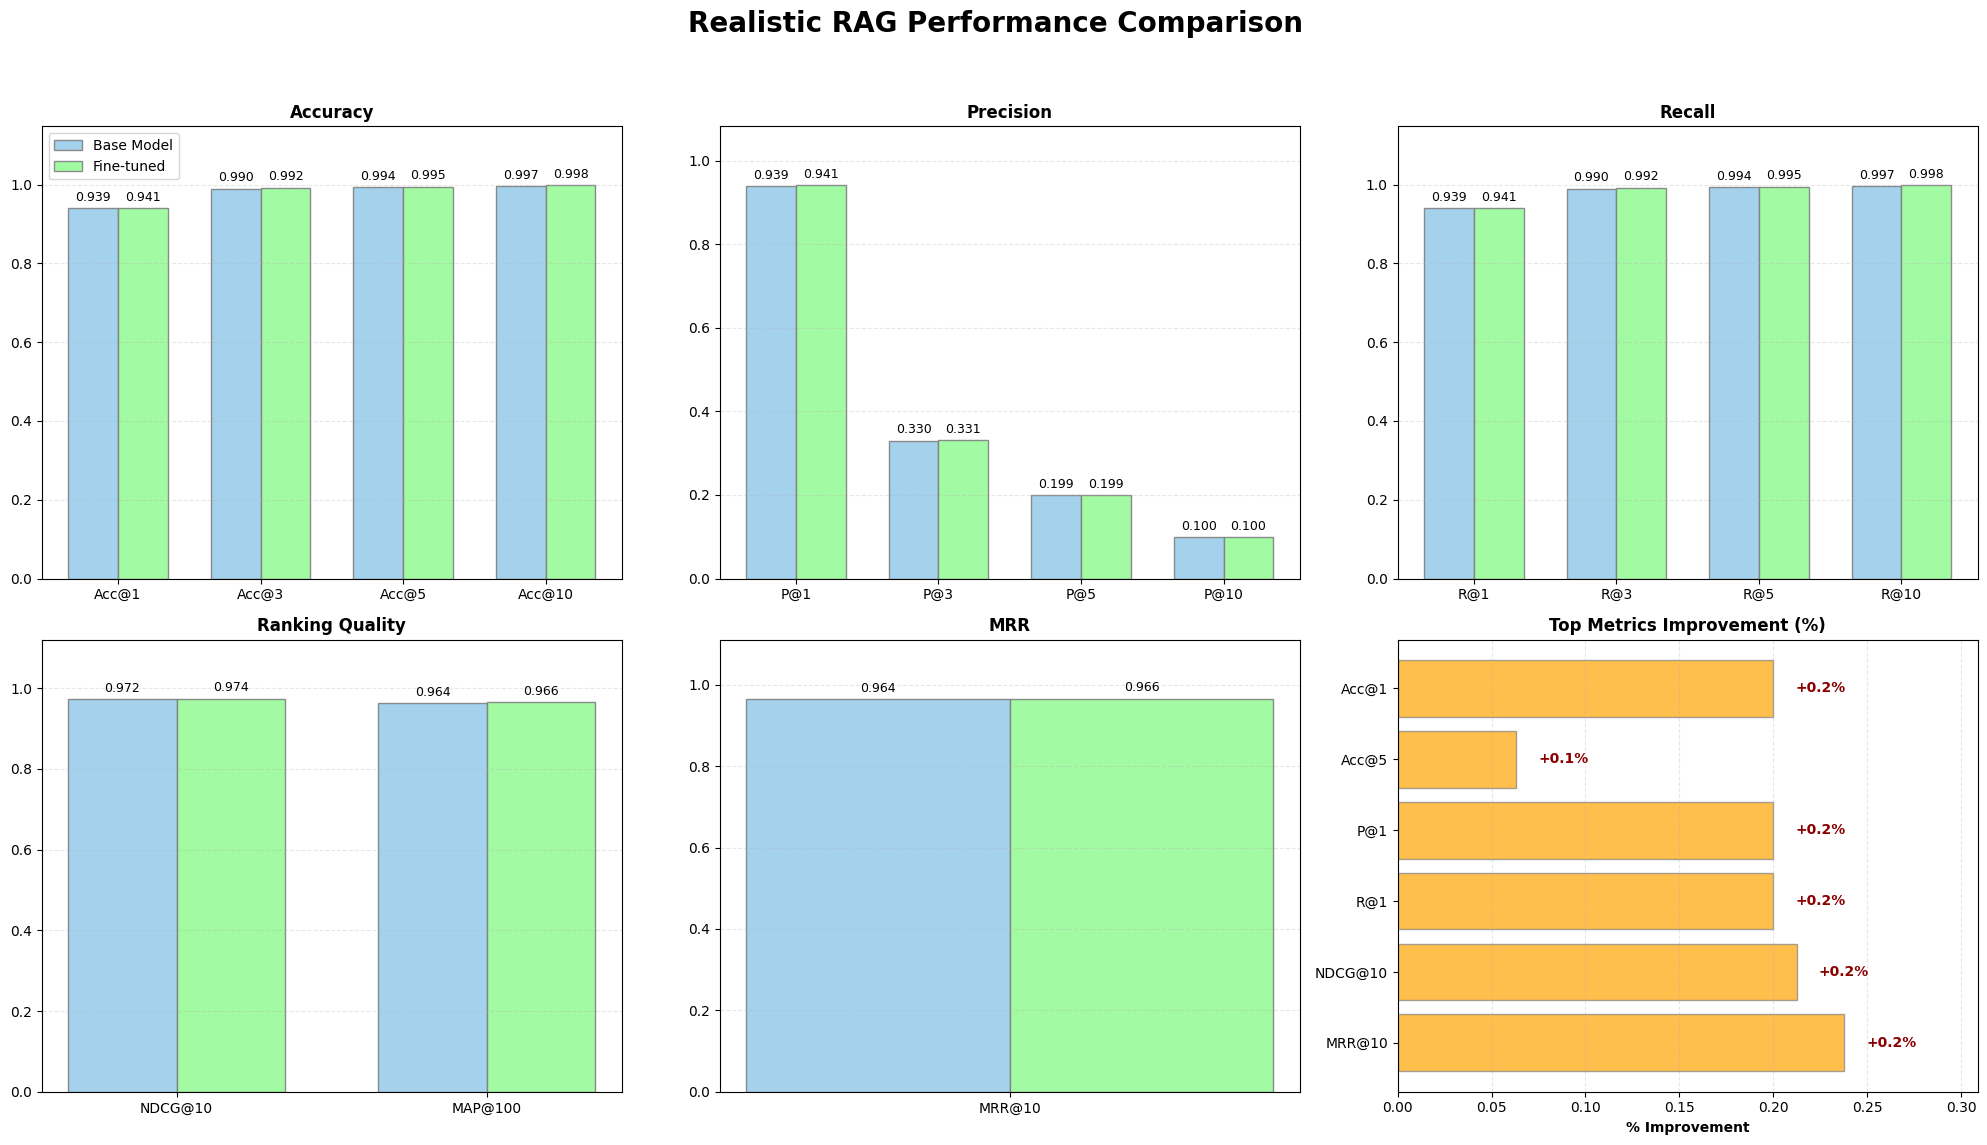

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_final(res_base, res_ft, evaluator_name=""):
    """
    Phiên bản Clean: Đã BỎ các chỉ số cộng thêm (+0.xx) màu xanh/đỏ.
    Chỉ hiển thị giá trị thực tế của từng cột.
    """

    # Kiểm tra dữ liệu
    if not res_base or not res_ft:
        print(" LỖI: Dữ liệu đầu vào bị rỗng!")
        return

    # 1. Xử lý Prefix key
    prefix = f"{evaluator_name}_" if evaluator_name else ""
    test_key = f"{prefix}cosine_accuracy@1"
    if test_key not in res_base:
        prefix = ""

    # Định nghĩa dữ liệu
    metrics_data = {
        "Accuracy": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        "Precision": [
            ("P@1", f"{prefix}cosine_precision@1"),
            ("P@3", f"{prefix}cosine_precision@3"),
            ("P@5", f"{prefix}cosine_precision@5"),
            ("P@10", f"{prefix}cosine_precision@10")
        ],
        "Recall": [
            ("R@1", f"{prefix}cosine_recall@1"),
            ("R@3", f"{prefix}cosine_recall@3"),
            ("R@5", f"{prefix}cosine_recall@5"),
            ("R@10", f"{prefix}cosine_recall@10")
        ],
        "Ranking Quality": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    def get_val(res, key):
        return res.get(key, 0.0)

    color_base = '#9ACEEB'
    color_ft = '#98FB98'

    # 2. Thiết lập khung hình
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle(f'Realistic RAG Performance Comparison{evaluator_name}', fontsize=20, fontweight='bold', y=0.98)

    ax_list = axes.flatten()

    # 3. VẼ CÁC BIỂU ĐỒ CỘT (1-5)
    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        rects1 = ax.bar(x - width/2, base_vals, width, label='Base Model', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, fontsize=10)

        # Tự động chỉnh chiều cao (Giảm khoảng trống thừa vì không còn text delta)
        max_val = max(max(base_vals, default=0), max(ft_vals, default=0))
        ax.set_ylim(0, max_val * 1.15 if max_val > 0 else 1.0)

        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if i == 0: ax.legend(loc='upper left', fontsize=10)

        # Hàm ghi số liệu thực tế (Màu đen)
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9, rotation=0)
        autolabel(rects1)
        autolabel(rects2)

        # --- ĐÃ XÓA VÒNG LẶP GHI TEXT DELTA (+0.xx) TẠI ĐÂY ---

    # 4. BIỂU ĐỒ 6: TỔNG HỢP (SUMMARY)
    # Giữ nguyên biểu đồ này vì bản thân nó là biểu đồ tăng trưởng
    ax_summary = ax_list[5]
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("P@1", f"{prefix}cosine_precision@1"),
        ("R@1", f"{prefix}cosine_recall@1"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]

    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        pct = ((f - b) / b) * 100 if b > 0 else 0
        pct_changes.append(pct)

    y_pos = np.arange(len(labels_sum))

    bars = ax_summary.barh(y_pos[::-1], pct_changes, color='orange', edgecolor='grey', alpha=0.7)

    max_pct = max([abs(p) for p in pct_changes]) if pct_changes else 10
    ax_summary.set_xlim(0, max_pct * 1.3)

    ax_summary.set_yticks(y_pos[::-1])
    ax_summary.set_yticklabels(labels_sum)
    ax_summary.set_xlabel('% Improvement', fontweight='bold')
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=12, fontweight='bold')
    ax_summary.grid(axis='x', linestyle='--', alpha=0.3)

    for i, v in enumerate(pct_changes):
        text_x = v + (max_pct * 0.05) if v >= 0 else 0
        ax_summary.text(text_x, len(pct_changes)-1-i, f"{v:+.1f}%",
                        va='center', fontweight='bold', color='darkred', fontsize=10)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# ===== GỌI HÀM =====
plot_rag_metrics_final(res_base_e5, res_ft_e5)


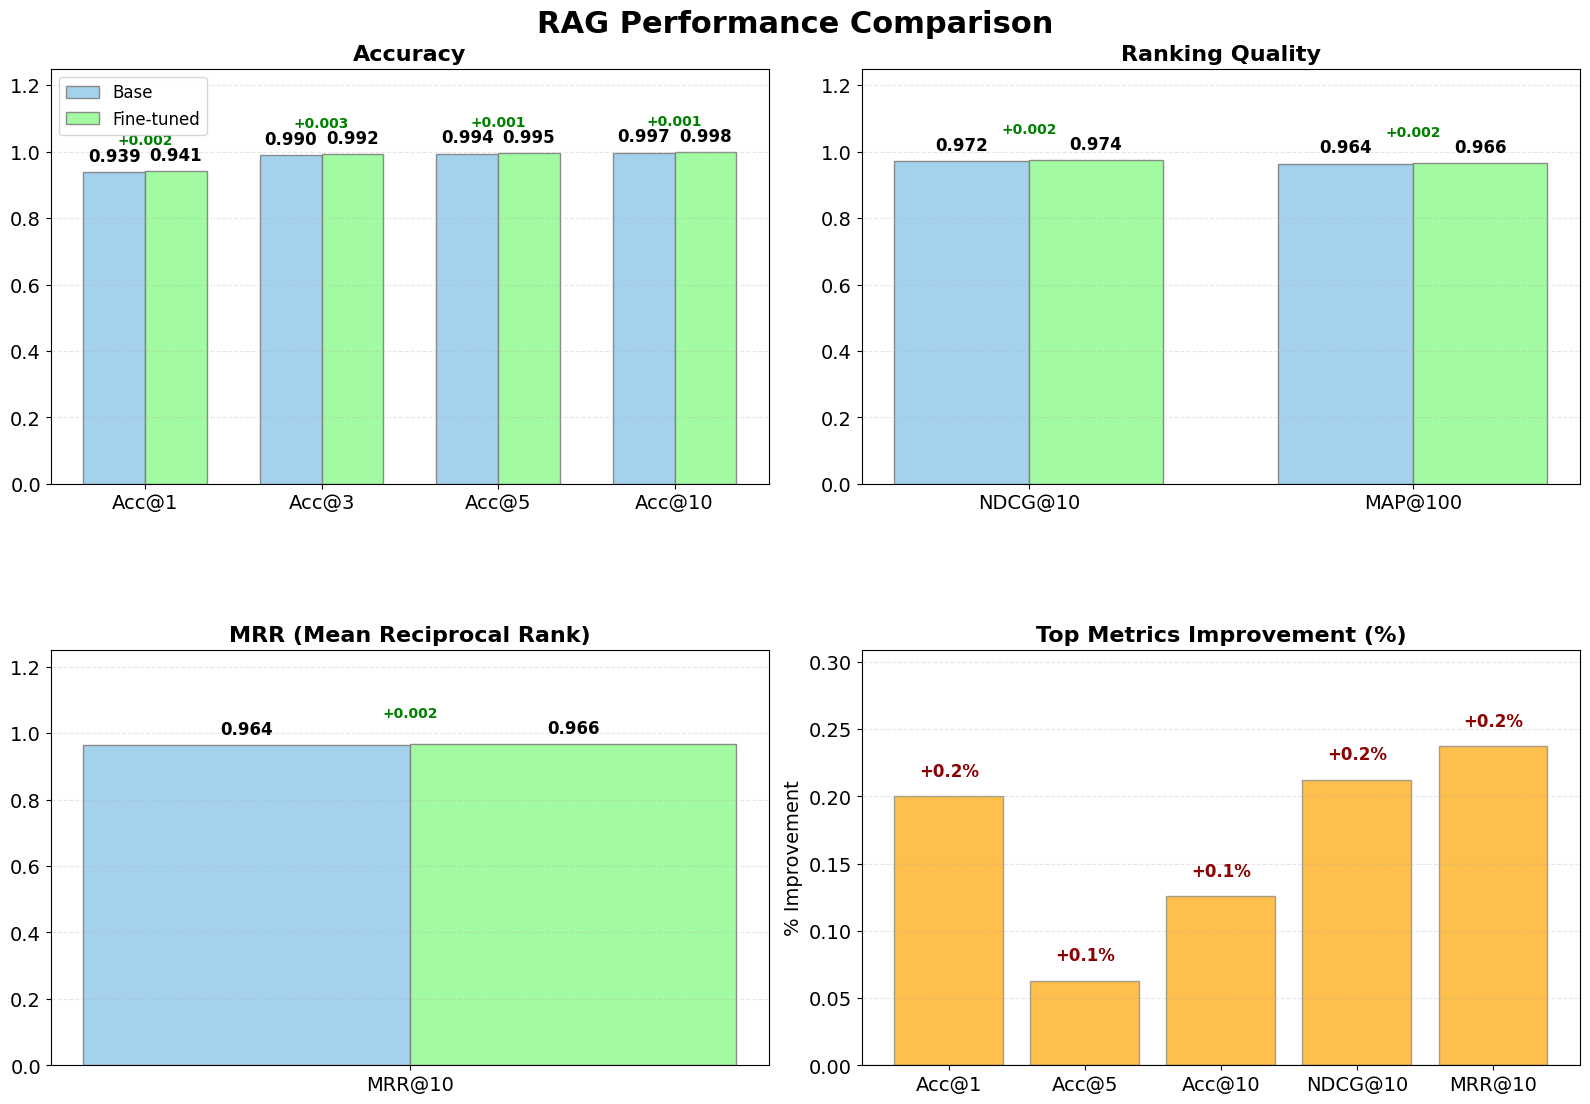

In [62]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_final(res_base, res_ft, evaluator_name=""):
    """
    Phiên bản Fix lỗi:
    1. Fix lỗi khoảng trắng thừa.
    2. Fix lỗi text bị nhảy (do offset cứng) bằng offset động.
    3. Fix lỗi cắt chữ trục X.
    """

    # ==========================================
    # 🔴 CẤU HÌNH CỠ CHỮ
    # ==========================================
    FONT_VAL_ON_BAR = 12
    FONT_AXIS_XY    = 14
    FONT_TITLE      = 16
    FONT_DELTA      = 10
    FONT_LEGEND     = 12
    # ==========================================

    # 1. Chuẩn bị dữ liệu
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    def get_val(res, key):
        return res.get(key, 0.0)

    metrics_data = {
        "Accuracy": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        "Ranking Quality": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    color_base = '#9ACEEB'
    color_ft = '#98FB98'

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'RAG Performance Comparison', fontsize=22, fontweight='bold')

    ax_list = axes.flatten()

    # 3. VÒNG LẶP VẼ 3 BIỂU ĐỒ ĐẦU TIÊN
    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        ax.set_title(title, fontsize=FONT_TITLE, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.25)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=FONT_AXIS_XY)

        if i == 0: ax.legend(loc='upper left', fontsize=FONT_LEGEND)

        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 5), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=FONT_VAL_ON_BAR, fontweight='bold')
        autolabel(rects1)
        autolabel(rects2)

        for j in range(len(labels)):
            diff = ft_vals[j] - base_vals[j]
            if abs(diff) > 0.0001:
                color = 'green' if diff > 0 else 'red'
                sign = '+' if diff > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.08,
                        f'{sign}{diff:.3f}', ha='center', color=color, fontweight='bold', fontsize=FONT_DELTA)

    # 4. BIỂU ĐỒ THỨ 4: TỔNG HỢP (FIX LỖI NHẢY TEXT TẠI ĐÂY)
    ax_summary = ax_list[3]
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("Acc@10", f"{prefix}cosine_accuracy@10"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]
    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        pct = ((f - b) / b) * 100 if b > 0 else 0
        pct_changes.append(pct)

    # Tính toán giới hạn trục Y và Offset động
    max_val = max(pct_changes) if pct_changes else 0
    min_val = min(pct_changes) if pct_changes else 0

    # Offset động = 5% của giá trị lớn nhất (để text luôn cách đều ngọn cột bất kể cột cao hay thấp)
    dynamic_offset = max(max_val, abs(min_val)) * 0.05
    if dynamic_offset == 0: dynamic_offset = 0.1 # Fallback nếu biểu đồ rỗng

    # Vẽ cột
    x_pos = np.arange(len(labels_sum))
    ax_summary.bar(x_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)

    ax_summary.set_xticks(x_pos)
    ax_summary.set_xticklabels(labels_sum)
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=FONT_TITLE, fontweight='bold')
    ax_summary.set_ylabel('% Improvement', fontsize=FONT_AXIS_XY)
    ax_summary.tick_params(axis='both', labelsize=FONT_AXIS_XY)
    ax_summary.grid(axis='y', linestyle='--', alpha=0.3)
    ax_summary.axhline(0, color='black', linewidth=0.8)

    # Ghi số % (Dùng dynamic_offset)
    for i, v in enumerate(pct_changes):
        # Nếu v dương -> cộng offset. Nếu v âm -> trừ offset.
        offset = dynamic_offset if v >= 0 else -dynamic_offset
        va_align = 'bottom' if v >= 0 else 'top'
        color_text = 'darkred' if v >= 0 else 'blue'

        ax_summary.text(i, v + offset, f"{v:+.1f}%",
                        ha='center', va=va_align,
                        fontweight='bold', color=color_text, fontsize=FONT_VAL_ON_BAR)

    # Set ylim
    if min_val < 0:
        limit_range = max(max_val, abs(min_val)) * 1.3
        ax_summary.set_ylim(-limit_range, limit_range)
    else:
        ax_summary.set_ylim(0, max_val * 1.3)

    plt.tight_layout()
    plt.subplots_adjust(bottom=0.1, hspace=0.4)
    plt.show()

# ===== GỌI HÀM =====
plot_rag_metrics_final(res_base_e5, res_ft_e5)

**FINE TUNING MODEL bkai-foundation-models/vietnamese-bi-encoder**

In [8]:
from sentence_transformers import SentenceTransformer

# ===== Load base model =====
BASE_MODEL_BKAI = "bkai-foundation-models/vietnamese-bi-encoder"
print("\n Đang tải model base...")
model_base_bkai = SentenceTransformer(BASE_MODEL_BKAI)

# ===== Tạo Evaluator (không ghi file) =====
ir_eval = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=qrels,
    mrr_at_k=[10],
    ndcg_at_k=[10],
    accuracy_at_k=[1, 3, 5, 10],
    precision_recall_at_k=[1, 3, 5, 10],
    map_at_k=[100],
    batch_size=64,
    # show_progress_bar=True,
)

# ===== Chạy đánh giá (không cần output_path) =====
print("\n=====  BASE MODEL =====")
res_base_bkai = ir_eval(model_base_bkai)

# In kết quả
print("===  Evaluation Results ===")
for metric, value in sorted(res_base_bkai.items()):
    print(f"{metric:25s}: {value:.4f}")



 Đang tải model base...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

bpe.codes: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/22.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/167 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/270 [00:00<?, ?B/s]


=====  BASE MODEL =====
===  Evaluation Results ===
cosine_accuracy@1        : 0.8078
cosine_accuracy@10       : 0.9574
cosine_accuracy@3        : 0.9067
cosine_accuracy@5        : 0.9343
cosine_map@100           : 0.8646
cosine_mrr@10            : 0.8629
cosine_ndcg@10           : 0.8862
cosine_precision@1       : 0.8078
cosine_precision@10      : 0.0957
cosine_precision@3       : 0.3022
cosine_precision@5       : 0.1869
cosine_recall@1          : 0.8078
cosine_recall@10         : 0.9574
cosine_recall@3          : 0.9067
cosine_recall@5          : 0.9343


In [ ]:

import os, math, torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
# from sentence_transformers.evaluation import InformationRetrievalEvaluator

os.environ["WANDB_DISABLED"] = "true"   # tắt hoàn toàn
os.environ["WANDB_SILENT"]   = "true"   # im lặng, không in banner
# os.environ["WANDB_MODE"]   = "offline"  # (tuỳ chọn) log offline, không cần login

# ===== 0) Cấu hình =====
BASE_MODEL = "bkai-foundation-models/vietnamese-bi-encoder"
FT_DIR_BKAI = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/Data/train_model/bkai_foundation_models_fine_tuning"
BATCH_SIZE, MAX_LEN, EPOCHS, LR, WARMUP_RT, EVAL_EVERY = 8, 256, 3, 2e-5, 0.1, 200
USE_AMP = True
os.makedirs(FT_DIR_BKAI, exist_ok=True)

BATCH_SIZE = 8
MAX_LEN    = 256
EPOCHS     = 8
LR         = 2e-5
WARMUP_RT  = 0.1
EVAL_EVERY = 200
USE_AMP    = True

# ===== 1) Hàm làm sạch (Strip Prefix) =====
def strip_e5_prefix(s: str) -> str:
    s = s.lstrip()
    for p in ("query: ", "passage: "):
        if s.lower().startswith(p):
            return s[len(p):].lstrip()
    return s

def to_bkai_examples(pairs):
    out = []
    for ex in pairs:
        q, p = ex.texts[:2]
        # Làm sạch cả query và passage
        out.append(InputExample(texts=[strip_e5_prefix(q), strip_e5_prefix(p)]))
    return out

# --- SỬA LỖI TẠI ĐÂY ---
# Áp dụng làm sạch cho CẢ HAI tập (Train và Val)
print(" Đang làm sạch dữ liệu (bỏ prefix query/passage)...")
train_examples_clean = to_bkai_examples(train_pairs) # <-- ĐÃ SỬA: dùng biến mới này
val_examples_clean   = to_bkai_examples(val_pairs)

print(f"   Sample Train Gốc: {train_pairs[0].texts[0]}")
print(f"   Sample Train Mới: {train_examples_clean[0].texts[0]}") # Kiểm tra xem mất chữ 'query:' chưa

# ===== 2) Chuẩn bị Evaluator =====
def build_ir_inputs(pairs):
    queries, corpus, qrels = {}, {}, {}
    for i, ex in enumerate(pairs):
        qid, did = f"q{i}", f"d{i}"
        queries[qid] = ex.texts[0]
        corpus[did]  = ex.texts[1]
        qrels[qid]   = {did}
    return queries, corpus, qrels

q_val, c_val, r_val = build_ir_inputs(val_examples_clean) # Dùng bản clean

ir_eval_val = InformationRetrievalEvaluator(
    queries=q_val, corpus=c_val, relevant_docs=r_val,
    ndcg_at_k=[10], mrr_at_k=[10], accuracy_at_k=[1,5], map_at_k=[100],
    batch_size=32, show_progress_bar=False, name="val"
)

# ===== 3) DataLoader & Training =====
# Đưa dữ liệu đã làm sạch vào DataLoader
train_loader = DataLoader(train_examples_clean, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

print(f"\n Đang load model: {BASE_MODEL}")
model = SentenceTransformer(BASE_MODEL)
model.max_seq_length = MAX_LEN
loss_fn = losses.MultipleNegativesRankingLoss(model)

steps_per_epoch = len(train_loader)
total_steps = steps_per_epoch * EPOCHS
warmup_steps = int(total_steps * WARMUP_RT)

model.fit(
    train_objectives=[(train_loader, loss_fn)],
    evaluator=ir_eval_val,
    epochs=EPOCHS,
    optimizer_params={'lr': LR},
    warmup_steps=warmup_steps,
    output_path=FT_DIR_BKAI,
    evaluation_steps=EVAL_EVERY,
    save_best_model=True,
    use_amp=USE_AMP and torch.cuda.is_available(),
    show_progress_bar=True
)
print(f" Saved best model to: {FT_DIR_BKAI}")


In [9]:
# =====  Đánh giá FINE-TUNED =====
from sentence_transformers import SentenceTransformer

FT_DIR_BKAI = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/bkai_foundation_models_fine_tuning_v1"

print("\n🔹 Đang tải FINE-TUNED model…")
model_ft = SentenceTransformer(FT_DIR_BKAI)

res_ft_bkai = ir_eval(model_ft)   # ✅ truyền model, KHÔNG truyền path
print("\n=== 📊 FINE-TUNED ===")
for k in sorted(res_ft_bkai.keys()):
    print(f"{k:22s}: {res_ft_bkai[k]:.6f}")



🔹 Đang tải FINE-TUNED model…

=== 📊 FINE-TUNED ===
cosine_accuracy@1     : 0.936756
cosine_accuracy@10    : 0.995617
cosine_accuracy@3     : 0.987477
cosine_accuracy@5     : 0.991234
cosine_map@100        : 0.962059
cosine_mrr@10         : 0.961841
cosine_ndcg@10        : 0.970381
cosine_precision@1    : 0.936756
cosine_precision@10   : 0.099562
cosine_precision@3    : 0.329159
cosine_precision@5    : 0.198247
cosine_recall@1       : 0.936756
cosine_recall@10      : 0.995617
cosine_recall@3       : 0.987477
cosine_recall@5       : 0.991234


In [10]:
# ===== 6️ In so sánh gọn gàng =====
def show_metrics(res_base: dict, res_ft: dict, evaluator):
    # tiền tố tên bộ test, vd "tourism-test_"
    prefix = f"{evaluator.name}_" if evaluator.name else ""
    keys = [
        "cosine_accuracy@1",
        "cosine_accuracy@5",
        "cosine_mrr@10",
        "cosine_ndcg@10",
        "cosine_map@100",
    ]
    def get(res, k):
        return round(res.get(prefix + k, 0.0), 4)

    print("\n📊 So sánh kết quả:")
    for k in keys:
        b = get(res_base_bkai, k)
        f = get(res_ft_bkai, k)
        delta = round(f - b, 4)
        rel = f"{(100*(f-b)):.2f}%" if b > 0 else "—"
        print(f"{k:>20}: base={b:.4f} | fine={f:.4f} | Δ={delta:+.4f} ({rel})")

show_metrics(res_base_bkai, res_ft_bkai, ir_eval)



📊 So sánh kết quả:
   cosine_accuracy@1: base=0.8078 | fine=0.9368 | Δ=+0.1290 (12.90%)
   cosine_accuracy@5: base=0.9343 | fine=0.9912 | Δ=+0.0569 (5.69%)
       cosine_mrr@10: base=0.8629 | fine=0.9618 | Δ=+0.0989 (9.89%)
      cosine_ndcg@10: base=0.8862 | fine=0.9704 | Δ=+0.0842 (8.42%)
      cosine_map@100: base=0.8646 | fine=0.9621 | Δ=+0.0975 (9.75%)


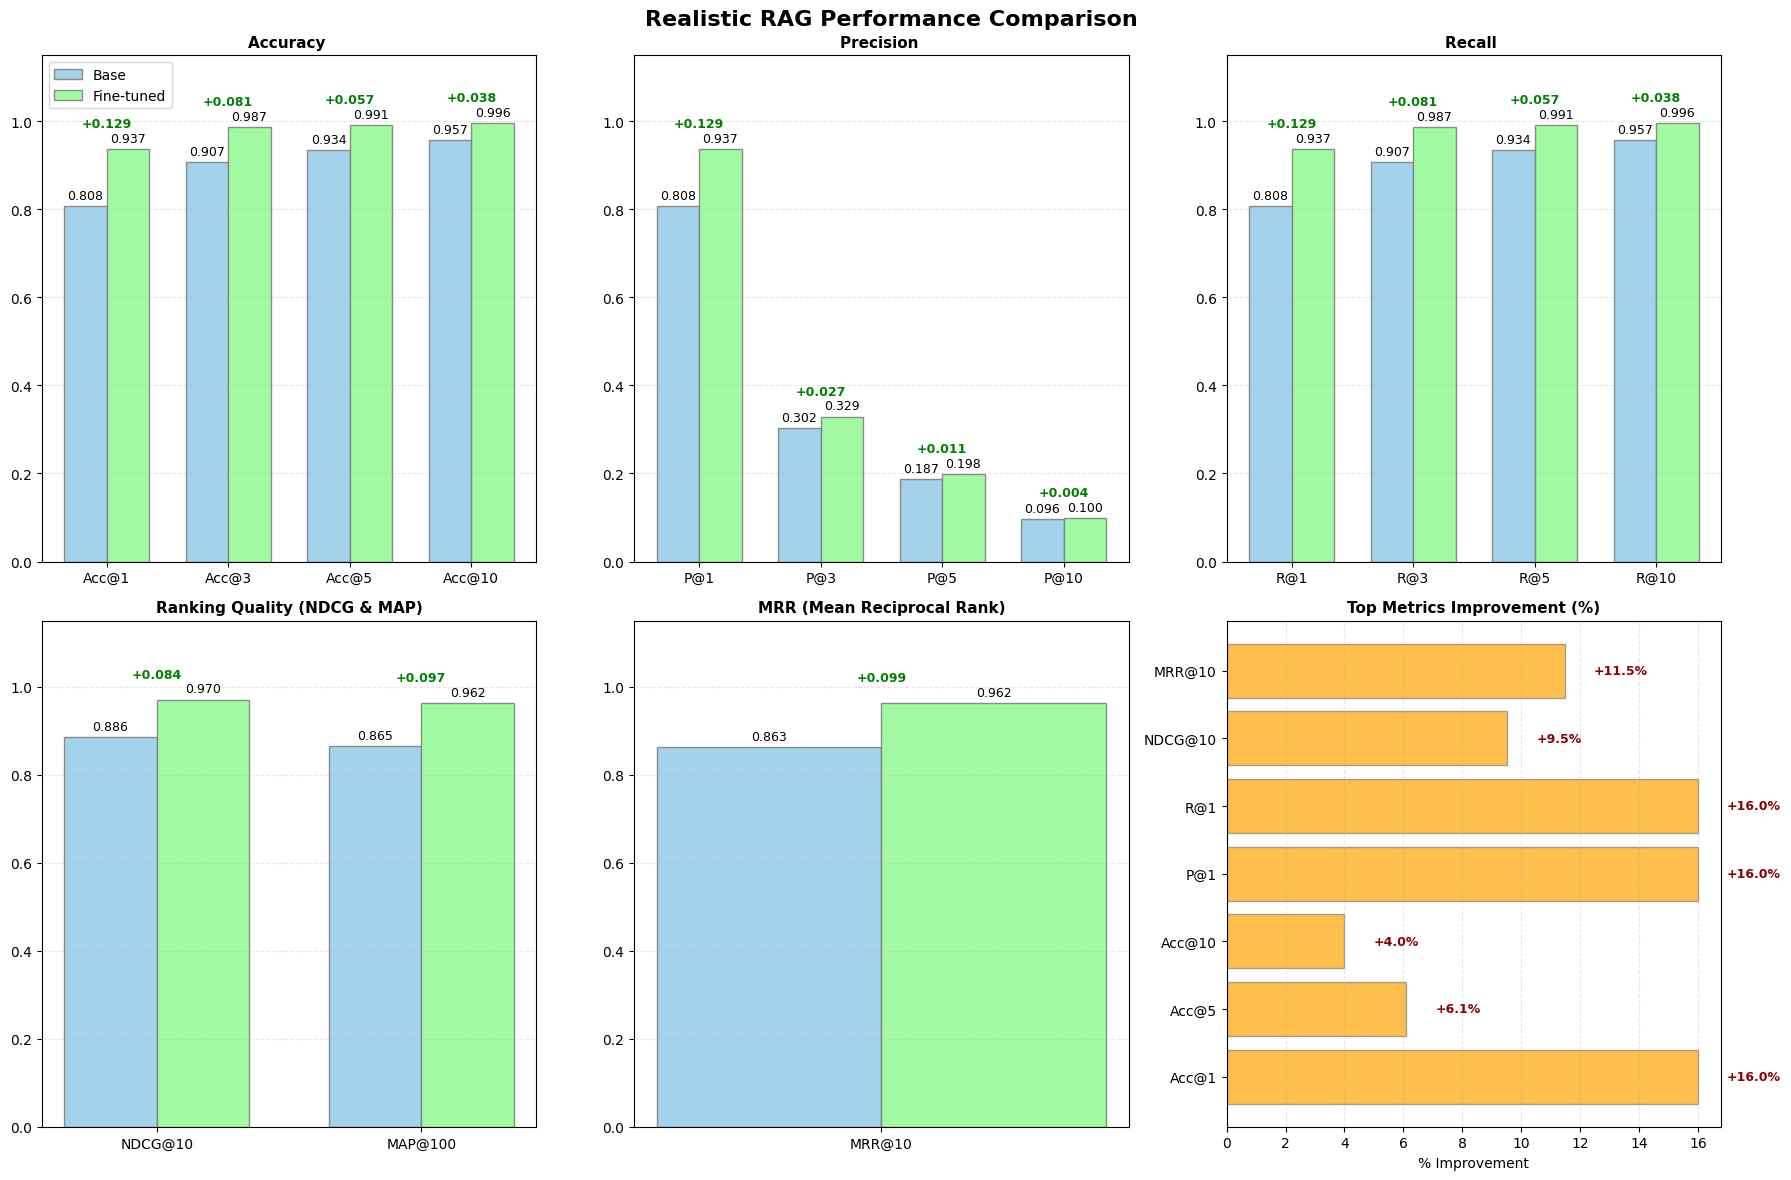

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_separated(res_base, res_ft, evaluator_name=""):
    """
    Vẽ 6 biểu đồ riêng biệt cho từng nhóm chỉ số:
    1. Accuracy, 2. Precision, 3. Recall, 4. Ranking, 5. MRR, 6. Tổng hợp %
    """
    # --- CẤU HÌNH CỠ CHỮ TẠI ĐÂY ---
    FONT_VAL_ON_BAR = 12   # Cỡ chữ số trên đầu cột (0.852...)
    FONT_AXIS_XY    = 16   # Cỡ chữ trục Oy và Ox (0.0, 0.2, Acc@1...)
    FONT_TITLE      = 16   # Cỡ chữ tiêu đề từng biểu đồ nhỏ
    FONT_DELTA      = 10   # Cỡ chữ phần tăng giảm (+0.xxx)

    # 1. Chuẩn bị dữ liệu
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    # Định nghĩa dữ liệu
    metrics_data = {
        # (Độ chính xác tìm kiếm)
        "Accuracy ": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        # (Độ chính xác tập trả về)
        "Precision ": [
            ("P@1", f"{prefix}cosine_precision@1"),
            ("P@3", f"{prefix}cosine_precision@3"),
            ("P@5", f"{prefix}cosine_precision@5"),
            ("P@10", f"{prefix}cosine_precision@10")
        ],
        # (Độ phủ thông tin)
        "Recall ": [
            ("R@1", f"{prefix}cosine_recall@1"),
            ("R@3", f"{prefix}cosine_recall@3"),
            ("R@5", f"{prefix}cosine_recall@5"),
            ("R@10", f"{prefix}cosine_recall@10")
        ],
        "Ranking Quality (NDCG & MAP)": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    def get_val(res, key):
        return res.get(key, 0.0)

    color_base = '#9ACEEB'  # Xanh dương nhạt
    color_ft = '#98FB98'    # Xanh lá nhạt

    # 2. Thiết lập khung hình: 2 hàng, 3 cột = 6 biểu đồ
    # Kích thước lớn  để các chữ không bị đè lên nhau
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Realistic RAG Performance Comparison {evaluator_name}', fontsize=16, fontweight='bold')

    ax_list = axes.flatten()

    # 3. VÒNG LẶP VẼ 5 NHÓM CHỈ SỐ ĐẦU TIÊN
    all_keys_flat = [] # Lưu lại để dùng cho biểu đồ tổng hợp cuối cùng

    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]
        all_keys_flat.extend(keys) # Gom key lại

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        # Vẽ cột
        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        # Trang trí
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.15)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if i == 0: ax.legend(loc='upper left')

        # Hàm ghi số liệu
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9)

        autolabel(rects1)
        autolabel(rects2)

        # Ghi Delta (Mức tăng)
        for j in range(len(labels)):
            improvement = ft_vals[j] - base_vals[j]
            if abs(improvement) > 0.001:
                color = 'green' if improvement > 0 else 'red'
                sign = '+' if improvement > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.05,
                        f'{sign}{improvement:.3f}',
                        ha='center', color=color, fontweight='bold', fontsize=9)

    # 4. BIỂU ĐỒ THỨ 6: TỔNG HỢP MỨC ĐỘ CẢI THIỆN (%)
    ax_summary = ax_list[5] # Vị trí cuối cùng (góc dưới phải)

    # Chọn lọc các chỉ số quan trọng để hiển thị ở bảng tổng hợp (tránh quá dày)
    # Lấy đại diện: Acc@1, Acc@5, P@1, R@1, NDCG@10, MRR@10
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("Acc@10", f"{prefix}cosine_accuracy@10"),
        ("P@1", f"{prefix}cosine_precision@1"),
        ("R@1", f"{prefix}cosine_recall@1"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]

    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        if b > 0:
            pct = ((f - b) / b) * 100
        else:
            pct = 0
        pct_changes.append(pct)

    y_pos = np.arange(len(labels_sum))
    # Đảo ngược thứ tự để Acc@1 nằm trên cùng
    ax_summary.barh(y_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)
    ax_summary.set_yticks(y_pos)
    ax_summary.set_yticklabels(labels_sum)
    ax_summary.set_xlabel('% Improvement')
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=11, fontweight='bold')
    ax_summary.grid(axis='x', linestyle='--', alpha=0.3)

    # Ghi số %
    for i, v in enumerate(pct_changes):
        ax_summary.text(v + (1 if v>=0 else -5), i, f"{v:+.1f}%", va='center', fontweight='bold', color='darkred', fontsize=9)

    plt.tight_layout()
    plt.show()

# ===== GỌI HÀM =====
eval_name = ir_eval.name if hasattr(ir_eval, 'name') else ""
plot_rag_metrics_separated(res_base_bkai, res_ft_bkai, eval_name)

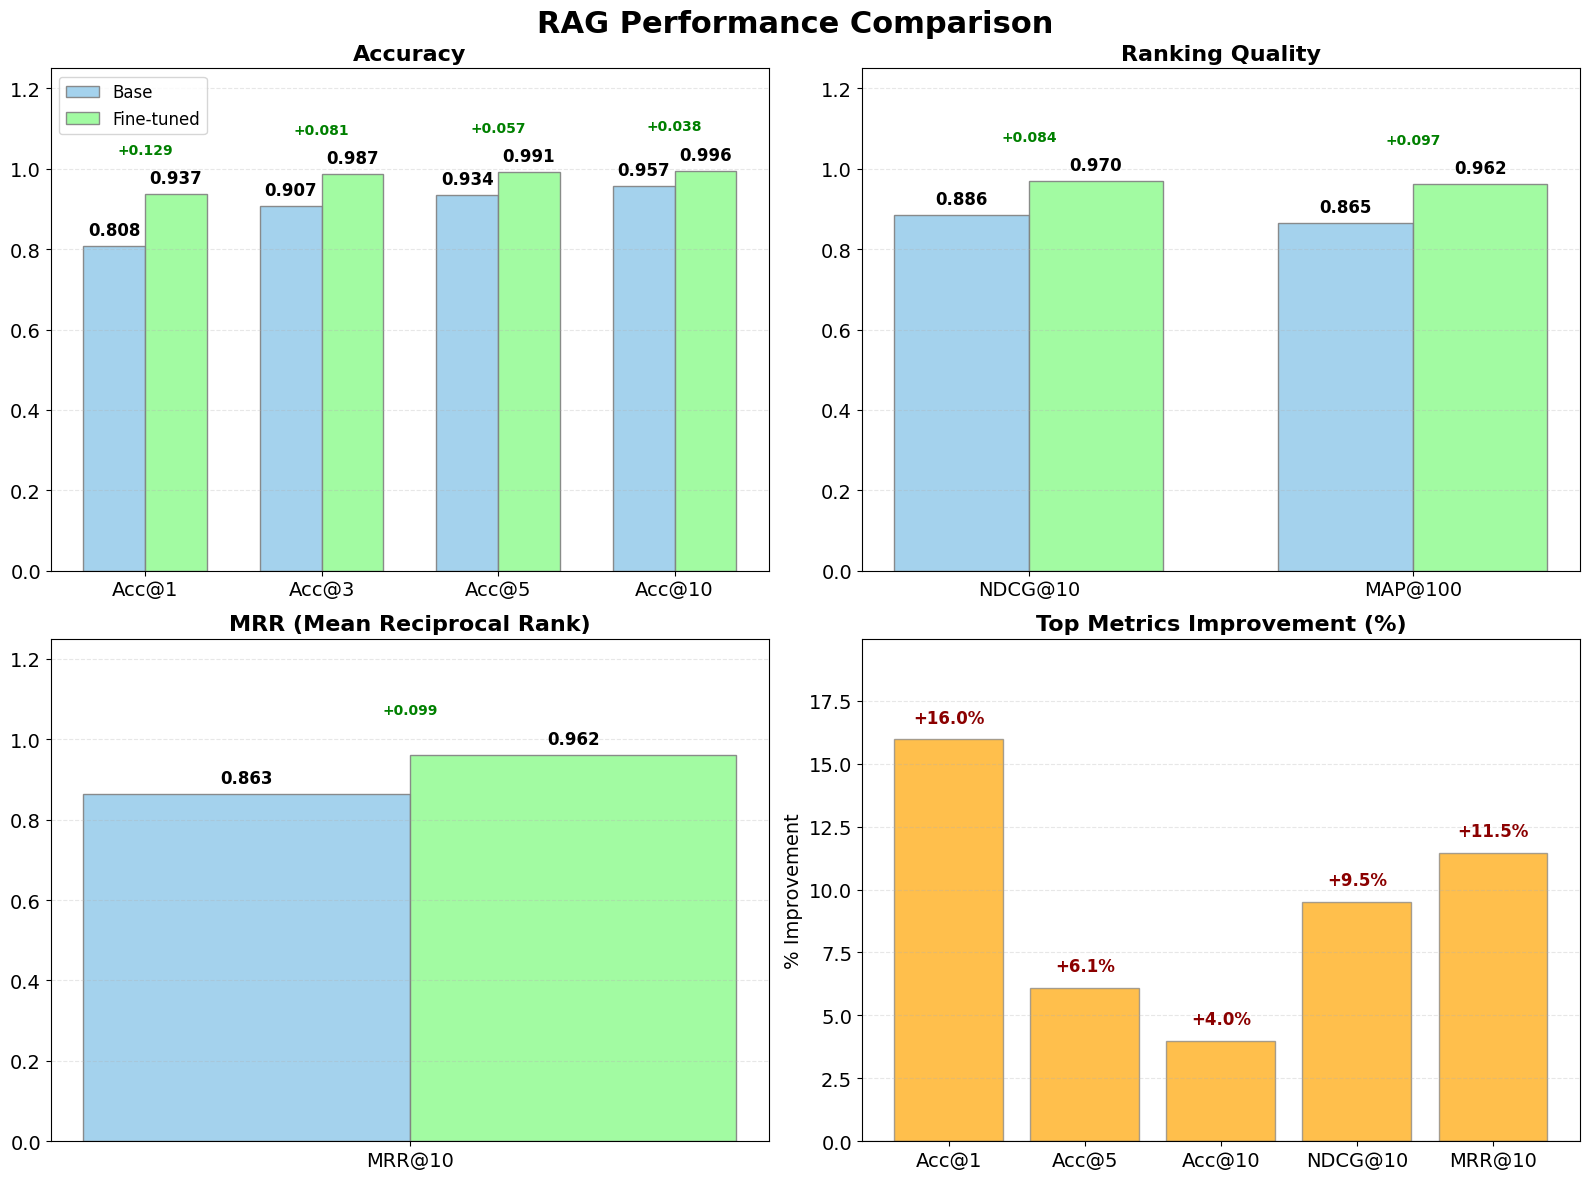

In [61]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_final(res_base, res_ft, evaluator_name=""):
    """
    Phiên bản Fix lỗi: Loại bỏ khoảng trắng thừa ở dưới biểu đồ cột.
    """

    # ==========================================
    # 🔴 CẤU HÌNH CỠ CHỮ
    # ==========================================
    FONT_VAL_ON_BAR = 12
    FONT_AXIS_XY    = 14
    FONT_TITLE      = 16
    FONT_DELTA      = 10
    FONT_LEGEND     = 12
    # ==========================================

    # 1. Chuẩn bị dữ liệu
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    def get_val(res, key):
        return res.get(key, 0.0)

    metrics_data = {
        "Accuracy": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        "Ranking Quality": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    color_base = '#9ACEEB'
    color_ft = '#98FB98'

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'RAG Performance Comparison', fontsize=22, fontweight='bold')

    ax_list = axes.flatten()

    # 3. VÒNG LẶP VẼ 3 BIỂU ĐỒ ĐẦU TIÊN
    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        ax.set_title(title, fontsize=FONT_TITLE, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.25)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=FONT_AXIS_XY)

        if i == 0: ax.legend(loc='upper left', fontsize=FONT_LEGEND)

        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 5), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=FONT_VAL_ON_BAR, fontweight='bold')
        autolabel(rects1)
        autolabel(rects2)

        for j in range(len(labels)):
            diff = ft_vals[j] - base_vals[j]
            if abs(diff) > 0.0001:
                color = 'green' if diff > 0 else 'red'
                sign = '+' if diff > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.1,
                        f'{sign}{diff:.3f}', ha='center', color=color, fontweight='bold', fontsize=FONT_DELTA)

    # 4. BIỂU ĐỒ THỨ 4: TỔNG HỢP (ĐÃ SỬA LỖI KHOẢNG TRẮNG)
    ax_summary = ax_list[3]
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("Acc@10", f"{prefix}cosine_accuracy@10"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]
    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        pct = ((f - b) / b) * 100 if b > 0 else 0
        pct_changes.append(pct)

    # Vẽ cột
    x_pos = np.arange(len(labels_sum))
    ax_summary.bar(x_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)

    ax_summary.set_xticks(x_pos)
    ax_summary.set_xticklabels(labels_sum)
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=FONT_TITLE, fontweight='bold')
    ax_summary.set_ylabel('% Improvement', fontsize=FONT_AXIS_XY)
    ax_summary.tick_params(axis='both', labelsize=FONT_AXIS_XY)
    ax_summary.grid(axis='y', linestyle='--', alpha=0.3)
    ax_summary.axhline(0, color='black', linewidth=0.8)

    # Ghi số %
    for i, v in enumerate(pct_changes):
        offset = 0.5 if v >= 0 else -0.5
        va_align = 'bottom' if v >= 0 else 'top'
        color_text = 'darkred' if v >= 0 else 'blue'

        ax_summary.text(i, v + offset, f"{v:+.1f}%",
                        ha='center', va=va_align,
                        fontweight='bold', color=color_text, fontsize=FONT_VAL_ON_BAR)

    # 🔴 FIX LỖI Ở ĐÂY: Logic tính ylim thông minh hơn
    if pct_changes:
        max_val = max(pct_changes) if pct_changes else 0
        min_val = min(pct_changes) if pct_changes else 0

        # Nếu có số âm: Nới rộng cả trên và dưới
        if min_val < 0:
            limit_range = max(max_val, abs(min_val)) + 5
            ax_summary.set_ylim(-limit_range, limit_range)
        else:
            # Nếu toàn số dương: Bắt đầu từ 0 (Hết khoảng trắng thừa)
            ax_summary.set_ylim(0, max_val * 1.25) # Nhân 1.25 để chừa chỗ cho text trên đầu cột

    plt.tight_layout()
    plt.show()

# ===== GỌI HÀM =====
plot_rag_metrics_final(res_base_bkai, res_ft_bkai)

**FINE TUNING MODEL**

In [46]:
from sentence_transformers import SentenceTransformer

# ===== Load base model =====
BASE_MODEL_v2 = "sentence-transformers/all-mpnet-base-v2"
print("\n Đang tải model base...")
model_base_v2 = SentenceTransformer(BASE_MODEL_v2)

# ===== Tạo Evaluator (không ghi file) =====
ir_eval = InformationRetrievalEvaluator(
    queries=queries,
    corpus=corpus,
    relevant_docs=qrels,
    mrr_at_k=[10],
    ndcg_at_k=[10],
    accuracy_at_k=[1, 3, 5, 10],
    precision_recall_at_k=[1, 3, 5, 10],
    map_at_k=[100],
    batch_size=64,
    show_progress_bar=True,
)

# ===== Chạy đánh giá (không cần output_path) =====
print("\n=====  BASE MODEL =====")
res_base_mpnet = ir_eval(model_base_v2)  #  bỏ output_path

# In kết quả
print("===  Evaluation Results ===")
for metric, value in sorted(res_base_mpnet.items()):
    print(f"{metric:25s}: {value:.4f}")



 Đang tải model base...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:27<00:00, 27.61s/it]

===  Evaluation Results ===
cosine_accuracy@1        : 0.1929
cosine_accuracy@10       : 0.3920
cosine_accuracy@3        : 0.2849
cosine_accuracy@5        : 0.3200
cosine_map@100           : 0.2600
cosine_mrr@10            : 0.2508
cosine_ndcg@10           : 0.2841
cosine_precision@1       : 0.1929
cosine_precision@10      : 0.0392
cosine_precision@3       : 0.0950
cosine_precision@5       : 0.0640
cosine_recall@1          : 0.1929
cosine_recall@10         : 0.3920
cosine_recall@3          : 0.2849
cosine_recall@5          : 0.3200


In [ ]:
import os, math, torch
from torch.utils.data import DataLoader
from sentence_transformers import SentenceTransformer, InputExample, losses
from sentence_transformers.evaluation import InformationRetrievalEvaluator

# ===== 0) Cấu hình =====
# Gợi ý cấu hình cho all-mpnet-base-v2:
# - MAX_LEN: 256 (MPNet hoạt động tốt ở 256)
# - BATCH_SIZE: 32 nếu đủ VRAM (T4 ~16GB vẫn ổn); nếu OOM, hạ xuống 16/8
# - LR: 2e-5 (ổn định cho MNRL), có thể 3e-5 nếu dữ liệu rất sạch/lớn
# - EPOCHS: 2–3 là hợp lý để tránh overfit
# - WARMUP_RT: 0.1 (10% bước warmup)
# - EVAL_EVERY: ~ mỗi 250–500 bước; hoặc 0 để tắt eval giữa chừng

os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_SILENT"]   = "true"

BASE_MODEL_MPNET_V2 = "sentence-transformers/all-mpnet-base-v2"
OUTPUT_DIR_MPNET_V2 = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/mpnet-base-v2_fine_tuning_v1"

BATCH_SIZE = 8
MAX_LEN    = 256
EPOCHS     = 8
LR         = 2e-5
WARMUP_RT  = 0.1
EVAL_EVERY = 200
USE_AMP    = True

os.makedirs(OUTPUT_DIR_MPNET_V2, exist_ok=True)

# ===== 1) Dữ liệu =====
# Yêu cầu sẵn 3 lists: train_pairs, val_pairs, test_pairs
# Mỗi phần tử là InputExample(texts=[query, positive])
# Nếu dữ liệu của bạn đang theo format E5 ("query: ...", "passage: ..."), nên bỏ prefix:

def strip_e5_prefix(s: str) -> str:
    s = s.lstrip()
    for p in ("query:", "passage:"):
        if s.lower().startswith(p):
            return s[len(p):].lstrip()
    return s

def normalize_pairs(pairs):
    out = []
    for ex in pairs:
        q, p = ex.texts[:2]
        out.append(InputExample(texts=[strip_e5_prefix(q), strip_e5_prefix(p)]))
    return out

# Chuẩn hóa tất cả splits (không chỉ val)
train_examples = normalize_pairs(train_pairs)
val_examples   = normalize_pairs(val_pairs)
test_examples  = normalize_pairs(test_pairs)

# Đầu vào cho IR Evaluator — qrels phải là dict {doc_id: 1}
def build_ir_inputs(pairs):
    queries, corpus, qrels = {}, {}, {}
    for i, ex in enumerate(pairs):
        qid, did = f"q{i}", f"d{i}"
        queries[qid]      = ex.texts[0].strip()
        corpus[did]       = ex.texts[1].strip()
        qrels[qid]        = {did: 1}   # <-- quan trọng: dùng {did: 1}, KHÔNG phải {did} set
    return queries, corpus, qrels

q_val, c_val, r_val = build_ir_inputs(val_examples)

# ===== 2) DataLoader =====
train_loader = DataLoader(train_examples, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# ===== 3) Model & Loss =====
model = SentenceTransformer(BASE_MODEL_MPNET_V2)
model.max_seq_length = MAX_LEN
loss_fn = losses.MultipleNegativesRankingLoss(model)

warmup_steps = max(1, int(len(train_loader) * EPOCHS * WARMUP_RT))

# ===== 4) Evaluator trên đúng val_pairs =====
ir_eval_val = InformationRetrievalEvaluator(
    queries=q_val,
    corpus=c_val,
    relevant_docs=r_val,
    ndcg_at_k=[10],
    mrr_at_k=[10],
    accuracy_at_k=[1, 3, 5, 10],
    map_at_k=[100],
    batch_size=64,
    show_progress_bar=True,
    write_csv=False,
    write_predictions=False,
    name="val"
)

# ===== 5) Train + eval giữa chừng + lưu best =====
model.fit(
    train_objectives=[(train_loader, loss_fn)],
    evaluator=ir_eval_val,
    epochs=EPOCHS,
    optimizer_params={'lr': LR},
    warmup_steps=warmup_steps,
    output_path=OUTPUT_DIR_MPNET_V2,
    evaluation_steps=EVAL_EVERY,      # đặt 0 nếu muốn train liền mạch
    save_best_model=True,
    use_amp=USE_AMP and torch.cuda.is_available(),
    show_progress_bar=True,
)

# ===== 6) Lưu best =====
best = SentenceTransformer(OUTPUT_DIR_MPNET_V2)
best.max_seq_length = MAX_LEN
best.save(OUTPUT_DIR_MPNET_V2)
print(" Saved best model to:", OUTPUT_DIR_MPNET_V2)



In [47]:
# =====  Đánh giá FINE-TUNED =====
from sentence_transformers import SentenceTransformer

FT_DIR_MPNET = "/content/drive/MyDrive/KY_9/KY_9_Final_Project/Data/train_model/mpnet-base-v2_fine_tuning_v1"

print("\n Đang tải FINE-TUNED model…")
model_ft = SentenceTransformer(FT_DIR_MPNET)

res_ft_mpnet = ir_eval(model_ft)   # ✅ truyền model, KHÔNG truyền path
print("\n=== 📊 FINE-TUNED ===")
for k in sorted(res_ft_mpnet.keys()):
    print(f"{k:22s}: {res_ft_mpnet[k]:.6f}")



 Đang tải FINE-TUNED model…


Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Corpus Chunks: 100%|██████████| 1/1 [00:26<00:00, 26.92s/it]


=== 📊 FINE-TUNED ===
cosine_accuracy@1     : 0.862868
cosine_accuracy@10    : 0.980589
cosine_accuracy@3     : 0.949906
cosine_accuracy@5     : 0.969317
cosine_map@100        : 0.910631
cosine_mrr@10         : 0.909626
cosine_ndcg@10        : 0.927330
cosine_precision@1    : 0.862868
cosine_precision@10   : 0.098059
cosine_precision@3    : 0.316635
cosine_precision@5    : 0.193863
cosine_recall@1       : 0.862868
cosine_recall@10      : 0.980589
cosine_recall@3       : 0.949906
cosine_recall@5       : 0.969317


In [48]:
# =====  In so sánh gọn gàng =====
def show_metrics(res_base: dict, res_ft: dict, evaluator):
    # tiền tố tên bộ test, vd "tourism-test_"
    prefix = f"{evaluator.name}_" if evaluator.name else ""
    keys = [
        "cosine_accuracy@1",
        "cosine_accuracy@5",
        "cosine_mrr@10",
        "cosine_ndcg@10",
        "cosine_map@100",
    ]
    def get(res, k):
        return round(res.get(prefix + k, 0.0), 4)

    print("\n So sánh kết quả :")
    for k in keys:
        b = get(res_base, k)
        f = get(res_ft, k)
        delta = round(f - b, 4)
        rel = f"{(100*(f-b)):.2f}%" if b > 0 else "—"
        print(f"{k:>20}: base={b:.4f} | fine={f:.4f} | Δ={delta:+.4f} ({rel})")

show_metrics(res_base_mpnet, res_ft_mpnet, ir_eval)



 So sánh kết quả :
   cosine_accuracy@1: base=0.1929 | fine=0.8629 | Δ=+0.6700 (67.00%)
   cosine_accuracy@5: base=0.3200 | fine=0.9693 | Δ=+0.6493 (64.93%)
       cosine_mrr@10: base=0.2508 | fine=0.9096 | Δ=+0.6588 (65.88%)
      cosine_ndcg@10: base=0.2841 | fine=0.9273 | Δ=+0.6432 (64.32%)
      cosine_map@100: base=0.2600 | fine=0.9106 | Δ=+0.6506 (65.06%)


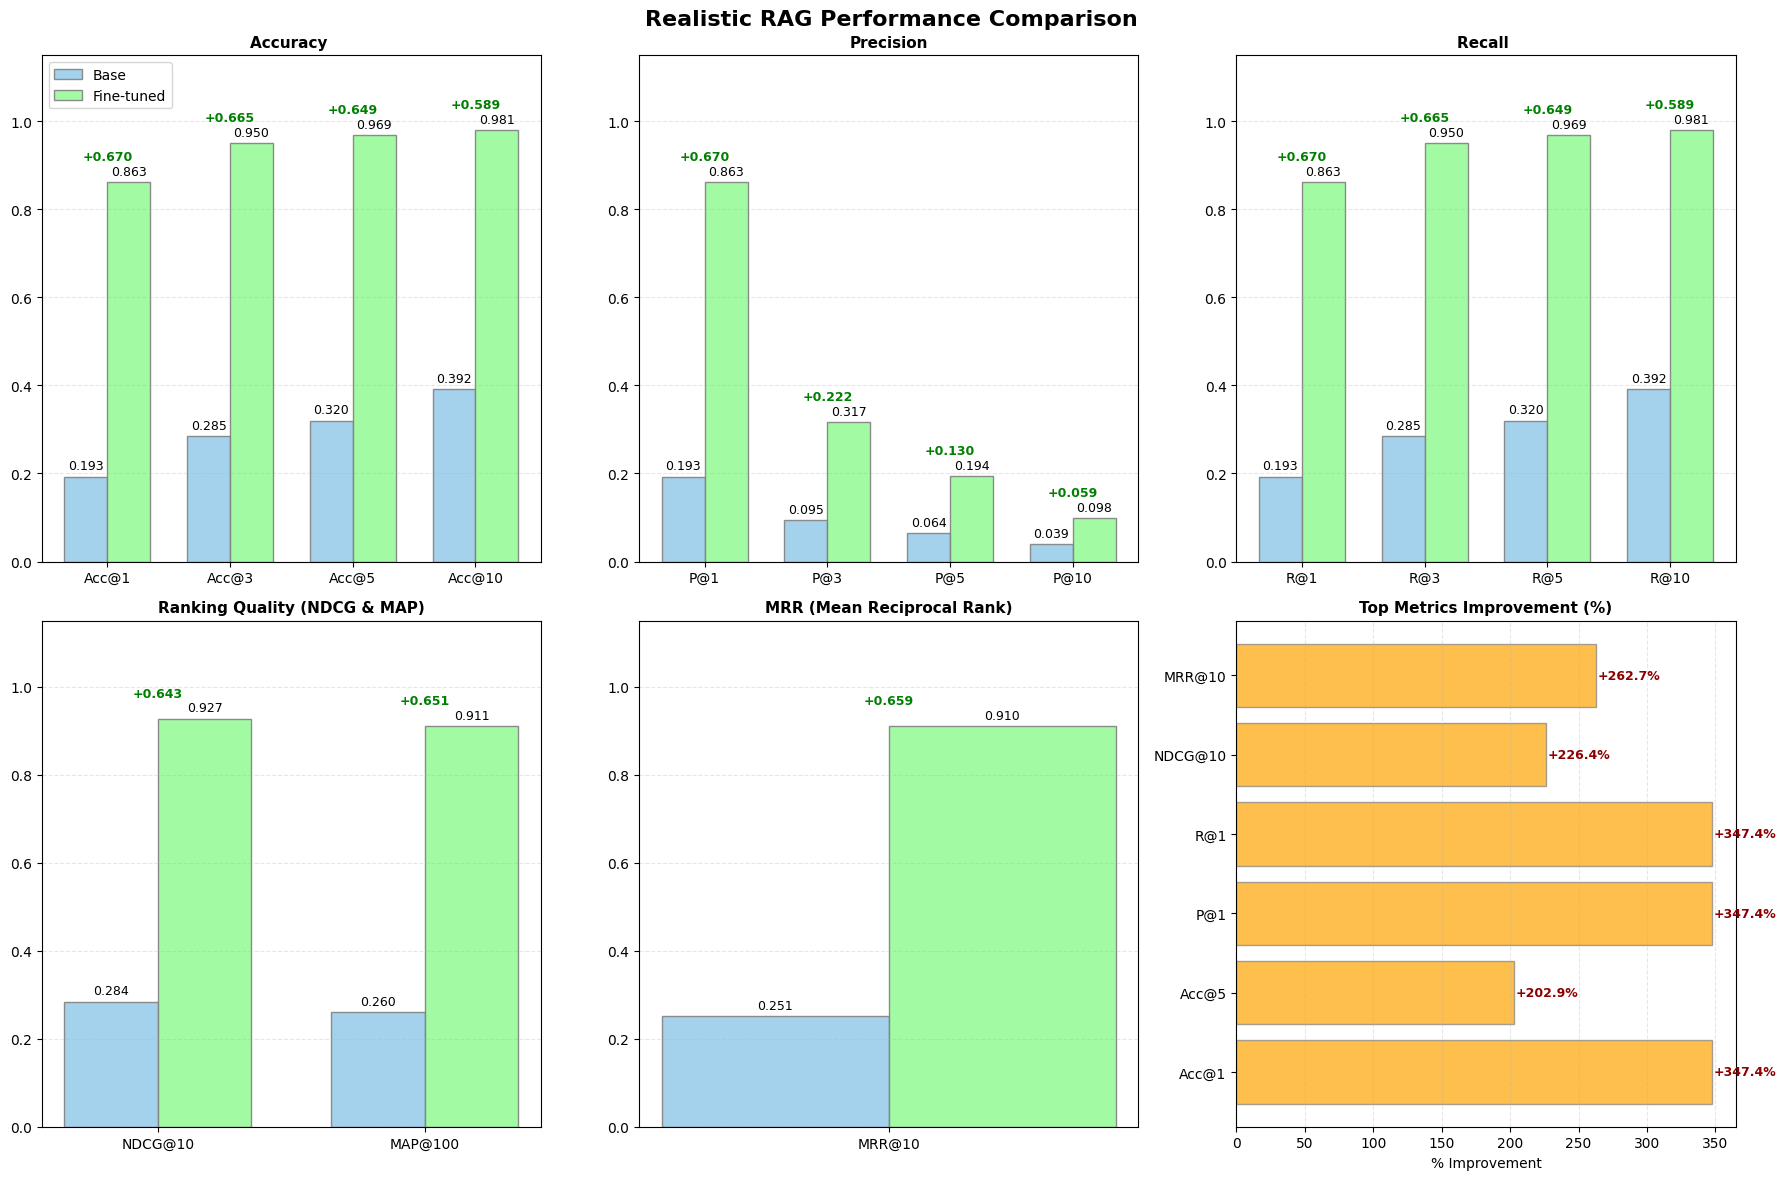

In [60]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_separated(res_base, res_ft, evaluator_name=""):
    """
    Vẽ 6 biểu đồ riêng biệt cho từng nhóm chỉ số:
    1. Accuracy, 2. Precision, 3. Recall, 4. Ranking, 5. MRR, 6. Tổng hợp %
    """

    # 1. Chuẩn bị dữ liệu
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    # Định nghĩa dữ liệu
    metrics_data = {
        # (Độ chính xác tìm kiếm)
        "Accuracy ": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        # (Độ chính xác tập trả về)
        "Precision": [
            ("P@1", f"{prefix}cosine_precision@1"),
            ("P@3", f"{prefix}cosine_precision@3"),
            ("P@5", f"{prefix}cosine_precision@5"),
            ("P@10", f"{prefix}cosine_precision@10")
        ],
        # (Độ phủ thông tin)
        "Recall ": [
            ("R@1", f"{prefix}cosine_recall@1"),
            ("R@3", f"{prefix}cosine_recall@3"),
            ("R@5", f"{prefix}cosine_recall@5"),
            ("R@10", f"{prefix}cosine_recall@10")
        ],
        "Ranking Quality (NDCG & MAP)": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    def get_val(res, key):
        return res.get(key, 0.0)

    color_base = '#9ACEEB'  # Xanh dương nhạt
    color_ft = '#98FB98'    # Xanh lá nhạt

    # 2. Thiết lập khung hình: 2 hàng, 3 cột = 6 biểu đồ
    # Kích thước lớn  để các chữ không bị đè lên nhau
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'Realistic RAG Performance Comparison {evaluator_name}', fontsize=16, fontweight='bold')

    ax_list = axes.flatten()

    # 3. VÒNG LẶP VẼ 5 NHÓM CHỈ SỐ ĐẦU TIÊN
    all_keys_flat = [] # Lưu lại để dùng cho biểu đồ tổng hợp cuối cùng

    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]
        all_keys_flat.extend(keys) # Gom key lại

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        # Vẽ cột
        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        # Trang trí
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.15)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        if i == 0: ax.legend(loc='upper left')

        # Hàm ghi số liệu
        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=9)

        autolabel(rects1)
        autolabel(rects2)

        # Ghi Delta (Mức tăng)
        for j in range(len(labels)):
            improvement = ft_vals[j] - base_vals[j]
            if abs(improvement) > 0.001:
                color = 'green' if improvement > 0 else 'red'
                sign = '+' if improvement > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.05,
                        f'{sign}{improvement:.3f}',
                        ha='center', color=color, fontweight='bold', fontsize=9)

    # 4. BIỂU ĐỒ THỨ 6: TỔNG HỢP MỨC ĐỘ CẢI THIỆN (%)
    ax_summary = ax_list[5] # Vị trí cuối cùng (góc dưới phải)

    # Chọn lọc các chỉ số quan trọng để hiển thị ở bảng tổng hợp (tránh quá dày)
    # Lấy đại diện: Acc@1, Acc@5, P@1, R@1, NDCG@10, MRR@10
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("P@1", f"{prefix}cosine_precision@1"),
        ("R@1", f"{prefix}cosine_recall@1"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]

    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        if b > 0:
            pct = ((f - b) / b) * 100
        else:
            pct = 0
        pct_changes.append(pct)

    y_pos = np.arange(len(labels_sum))
    # Đảo ngược thứ tự để Acc@1 nằm trên cùng
    ax_summary.barh(y_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)
    ax_summary.set_yticks(y_pos)
    ax_summary.set_yticklabels(labels_sum)
    ax_summary.set_xlabel('% Improvement')
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=11, fontweight='bold')
    ax_summary.grid(axis='x', linestyle='--', alpha=0.3)

    # Ghi số %
    for i, v in enumerate(pct_changes):
        ax_summary.text(v + (1 if v>=0 else -5), i, f"{v:+.1f}%", va='center', fontweight='bold', color='darkred', fontsize=9)

    plt.tight_layout()
    plt.show()

# ===== GỌI HÀM =====
eval_name = ir_eval.name if hasattr(ir_eval, 'name') else ""
plot_rag_metrics_separated(res_base_mpnet, res_ft_mpnet, eval_name)

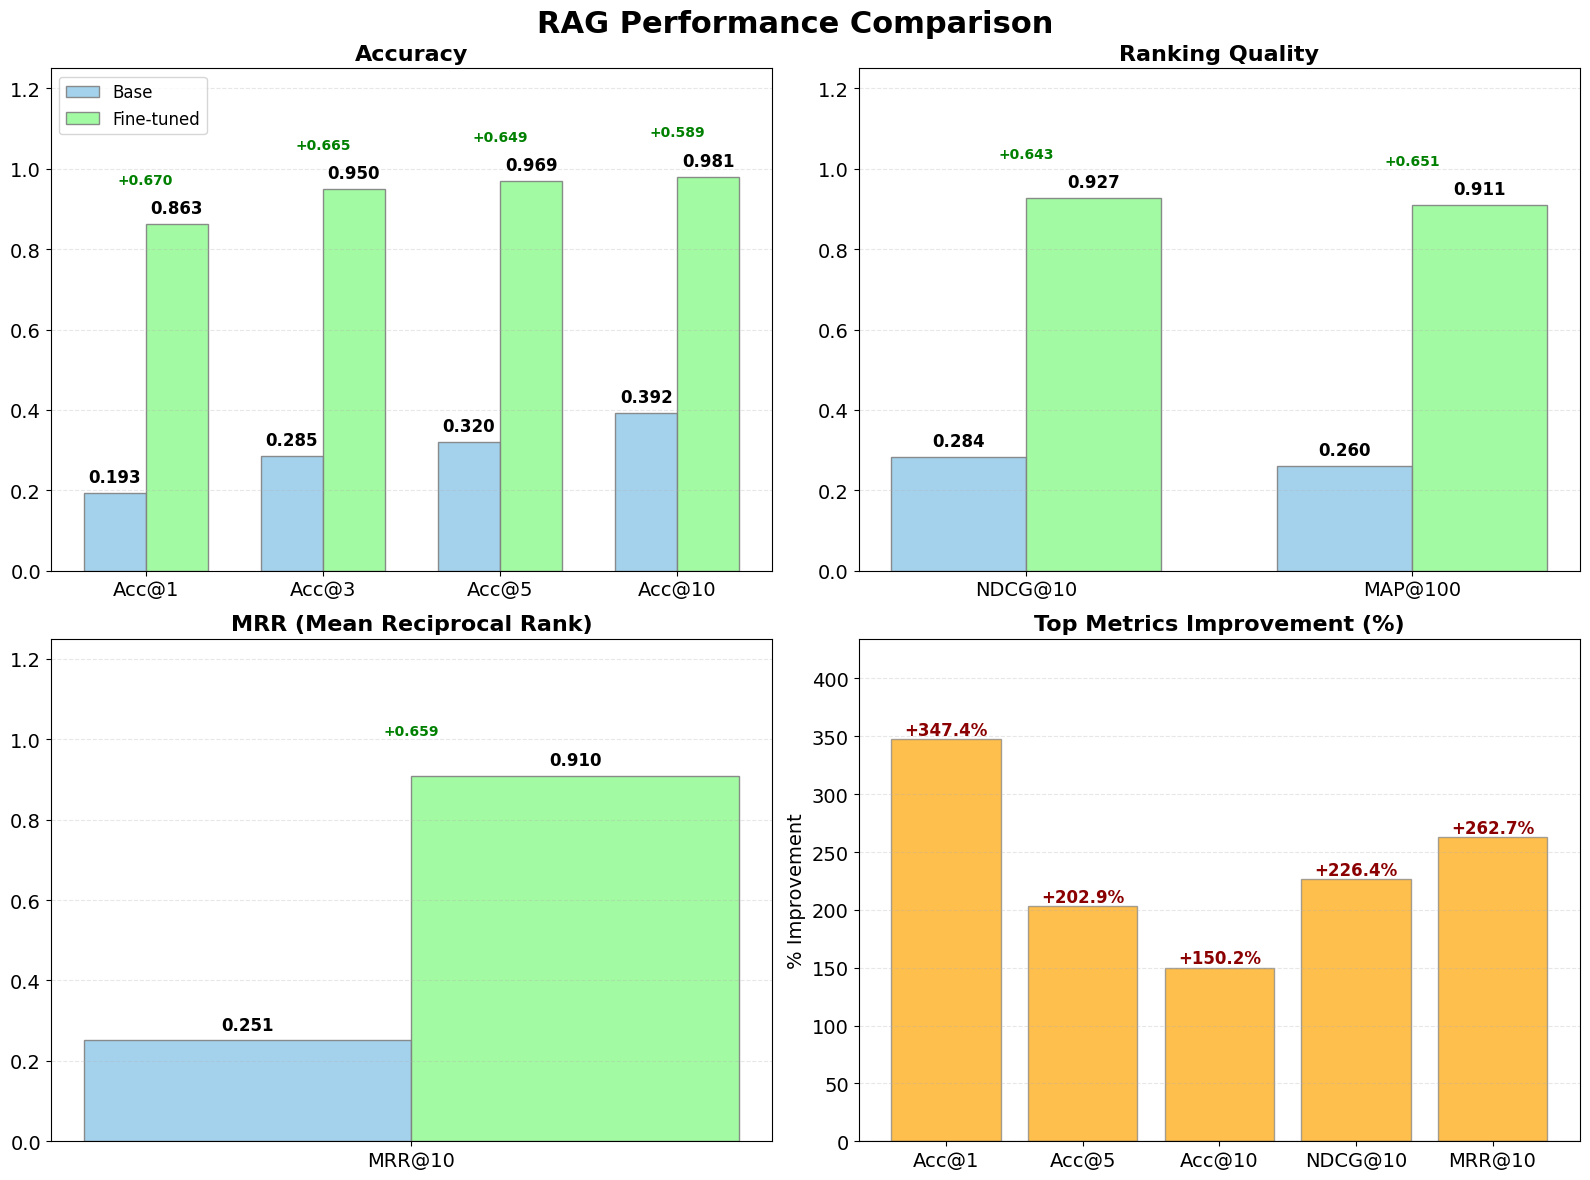

In [59]:
import matplotlib.pyplot as plt
import numpy as np

def plot_rag_metrics_final(res_base, res_ft, evaluator_name=""):
    """
    Phiên bản Fix lỗi: Loại bỏ khoảng trắng thừa ở dưới biểu đồ cột.
    """

    # ==========================================
    # 🔴 CẤU HÌNH CỠ CHỮ
    # ==========================================
    FONT_VAL_ON_BAR = 12
    FONT_AXIS_XY    = 14
    FONT_TITLE      = 16
    FONT_DELTA      = 10
    FONT_LEGEND     = 12
    # ==========================================

    # 1. Chuẩn bị dữ liệu
    prefix = f"{evaluator_name}_" if evaluator_name else ""

    def get_val(res, key):
        return res.get(key, 0.0)

    metrics_data = {
        "Accuracy": [
            ("Acc@1", f"{prefix}cosine_accuracy@1"),
            ("Acc@3", f"{prefix}cosine_accuracy@3"),
            ("Acc@5", f"{prefix}cosine_accuracy@5"),
            ("Acc@10", f"{prefix}cosine_accuracy@10")
        ],
        "Ranking Quality": [
            ("NDCG@10", f"{prefix}cosine_ndcg@10"),
            ("MAP@100", f"{prefix}cosine_map@100")
        ],
        "MRR (Mean Reciprocal Rank)": [
            ("MRR@10", f"{prefix}cosine_mrr@10")
        ]
    }

    color_base = '#9ACEEB'
    color_ft = '#98FB98'

    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    fig.suptitle(f'RAG Performance Comparison', fontsize=22, fontweight='bold')

    ax_list = axes.flatten()

    # 3. VÒNG LẶP VẼ 3 BIỂU ĐỒ ĐẦU TIÊN
    for i, (title, keys) in enumerate(metrics_data.items()):
        ax = ax_list[i]

        labels = [k[0] for k in keys]
        base_vals = [get_val(res_base, k[1]) for k in keys]
        ft_vals = [get_val(res_ft, k[1]) for k in keys]

        x = np.arange(len(labels))
        width = 0.35

        rects1 = ax.bar(x - width/2, base_vals, width, label='Base', color=color_base, edgecolor='grey', alpha=0.9)
        rects2 = ax.bar(x + width/2, ft_vals, width, label='Fine-tuned', color=color_ft, edgecolor='grey', alpha=0.9)

        ax.set_title(title, fontsize=FONT_TITLE, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels)
        ax.set_ylim(0, 1.25)
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.tick_params(axis='both', which='major', labelsize=FONT_AXIS_XY)

        if i == 0: ax.legend(loc='upper left', fontsize=FONT_LEGEND)

        def autolabel(rects):
            for rect in rects:
                height = rect.get_height()
                ax.annotate(f'{height:.3f}',
                            xy=(rect.get_x() + rect.get_width() / 2, height),
                            xytext=(0, 5), textcoords="offset points",
                            ha='center', va='bottom',
                            fontsize=FONT_VAL_ON_BAR, fontweight='bold')
        autolabel(rects1)
        autolabel(rects2)

        for j in range(len(labels)):
            diff = ft_vals[j] - base_vals[j]
            if abs(diff) > 0.0001:
                color = 'green' if diff > 0 else 'red'
                sign = '+' if diff > 0 else ''
                ax.text(j, max(base_vals[j], ft_vals[j]) + 0.1,
                        f'{sign}{diff:.3f}', ha='center', color=color, fontweight='bold', fontsize=FONT_DELTA)

    # 4. BIỂU ĐỒ THỨ 4: TỔNG HỢP (ĐÃ SỬA LỖI KHOẢNG TRẮNG)
    ax_summary = ax_list[3]
    summary_keys = [
        ("Acc@1", f"{prefix}cosine_accuracy@1"),
        ("Acc@5", f"{prefix}cosine_accuracy@5"),
        ("Acc@10", f"{prefix}cosine_accuracy@10"),
        ("NDCG@10", f"{prefix}cosine_ndcg@10"),
        ("MRR@10", f"{prefix}cosine_mrr@10")
    ]
    labels_sum = [k[0] for k in summary_keys]
    pct_changes = []

    for _, key_full in summary_keys:
        b = get_val(res_base, key_full)
        f = get_val(res_ft, key_full)
        pct = ((f - b) / b) * 100 if b > 0 else 0
        pct_changes.append(pct)

    # Vẽ cột
    x_pos = np.arange(len(labels_sum))
    ax_summary.bar(x_pos, pct_changes, color='orange', edgecolor='grey', alpha=0.7)

    ax_summary.set_xticks(x_pos)
    ax_summary.set_xticklabels(labels_sum)
    ax_summary.set_title('Top Metrics Improvement (%)', fontsize=FONT_TITLE, fontweight='bold')
    ax_summary.set_ylabel('% Improvement', fontsize=FONT_AXIS_XY)
    ax_summary.tick_params(axis='both', labelsize=FONT_AXIS_XY)
    ax_summary.grid(axis='y', linestyle='--', alpha=0.3)
    ax_summary.axhline(0, color='black', linewidth=0.8)

    # Ghi số %
    for i, v in enumerate(pct_changes):
        offset = 0.5 if v >= 0 else -0.5
        va_align = 'bottom' if v >= 0 else 'top'
        color_text = 'darkred' if v >= 0 else 'blue'

        ax_summary.text(i, v + offset, f"{v:+.1f}%",
                        ha='center', va=va_align,
                        fontweight='bold', color=color_text, fontsize=FONT_VAL_ON_BAR)

    if pct_changes:
        max_val = max(pct_changes) if pct_changes else 0
        min_val = min(pct_changes) if pct_changes else 0

        # Nếu có số âm: Nới rộng cả trên và dưới
        if min_val < 0:
            limit_range = max(max_val, abs(min_val)) + 5
            ax_summary.set_ylim(-limit_range, limit_range)
        else:
            # Nếu toàn số dương: Bắt đầu từ 0 (Hết khoảng trắng thừa)
            ax_summary.set_ylim(0, max_val * 1.25) # Nhân 1.25 để chừa chỗ cho text trên đầu cột

    plt.tight_layout()
    plt.show()

# ===== GỌI HÀM =====
plot_rag_metrics_final(res_base_mpnet, res_ft_mpnet, eval_name)